### Downstream analysis KAIJU, module: tax_classification_rb
Raw reads count are aggregated for all the samples using the geomosaic command:
```bash
geomosaic gather -s gmsetup -p kaiju
```

In [1]:
# Imports
library(phyloseq)
library(readr)
library(dplyr)
library(tidyr)
library(stringr)
library(ggplot2)
library(vegan)
library(microbiome)
library(svglite)
library(cowplot)
options(readr.show_col_types = FALSE)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: permute


microbiome R package (microbiome.github.com)
    


 Copyright (C) 2011-2025 Leo Lahti, 
    Sudarshan Shetty et al. <microbiome.github.io>
    
 
    Note: we recommend switching to the SummarizedExperiment
    framework, see microbiome.github.io/OMA and the mia package.
    Minimum maintenance is provided microbiome R package but the
    development efforts have switched to mia.


Attaching package: ‘microbiome’


The following object is masked from ‘package:vegan’:

    diversity


The following object is masked from ‘package:ggplot2’:

    alpha


The following object is masked from ‘package:base’:

    transform




In [2]:
theme_glab <- function(base_size = 11, base_family = "") {
  theme_bw(base_size = base_size, base_family = base_family) %+replace%
    theme(
      legend.background = element_blank(),
      legend.title      = element_text(
        color = rgb(100, 100, 100, maxColorValue = 255),
        size = rel(0.65),
        hjust = 0
      ),
      legend.text       = element_text(
        color = rgb(100, 100, 100, maxColorValue = 255),
        size = rel(0.65)
      ),
      legend.key.size   = unit(0.8, "lines"),
      plot.title        = element_text(
        color = rgb(100, 100, 100, maxColorValue = 255),
        hjust = 0.5, 
        face = "bold"
      ),
      axis.title        = element_text(
        color = rgb(100, 100, 100, maxColorValue = 255),
        size = rel(0.65)
      ),
      axis.text         = element_text(
        color = rgb(100, 100, 100, maxColorValue = 255),
        size = rel(0.65)
      ),
      panel.grid.major  = element_blank(),
      panel.grid.minor  = element_blank(),
      panel.border      = element_rect(
        fill = NA,
        colour = rgb(100, 100, 100, maxColorValue = 255)
      ),
      complete = TRUE
    )
}

In [3]:
options(rep.plot.width=16)
options(rep.plot.length=10)

In [4]:
read_kaiju <- function(level) {
  otu <- as.data.frame(read_delim(paste0("../tables/gm_gathering/kaiju/",level,"_reads.tsv"), 
  delim = "\t"
  ))
  otu$ID <- paste0("ID", seq_len(nrow(otu)))
  
  taxa <- otu[, c("ID", level)]
  colnames(taxa) <- c("ID", "Taxa_level")
  
  rownames(taxa) <- taxa$ID
  taxa <- taxa %>%
    mutate(
      Taxa_level = str_remove(Taxa_level, ";$"),
      Taxa_level = case_when(
        Taxa_level %in% c(
          "unclassified",
          "Viruses",
          paste0("cannot be assigned to a (non-viral) ", level)
        ) ~ paste(Taxa_level, Taxa_level, Taxa_level, Taxa_level, Taxa_level, sep = ";"),
        TRUE ~ Taxa_level
      )
    ) %>%
    separate(
      Taxa_level,
      into = c("Kingdom", "Phylum", "Class", "Order", "Family", "Genus", "Species"),
      sep = ";",
      fill = "right"
    )
  
  taxa$ID <- NULL
  
  rownames(otu) <- otu$ID
  otu$ID <- NULL
  otu[[level]] <- NULL

  return(list(otu=otu, taxa=taxa))
}

In [5]:
output_dir <- "../figures/kaiju/"
env <- as.data.frame(read_delim("../tables/cr18_env_geomosaicPlot.csv", 
                  delim = ",",
                  skip = 1, 
                  locale = locale(decimal_mark = ",")))
                  
rownames(env) <- env$Geomosaic_sample
env$Geomosaic_sample <- NULL
                  

Warning message:
“`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.
ℹ The deprecated feature was likely used in the phyloseq package.
  Please report the issue at <https://github.com/joey711/phyloseq/issues>.”


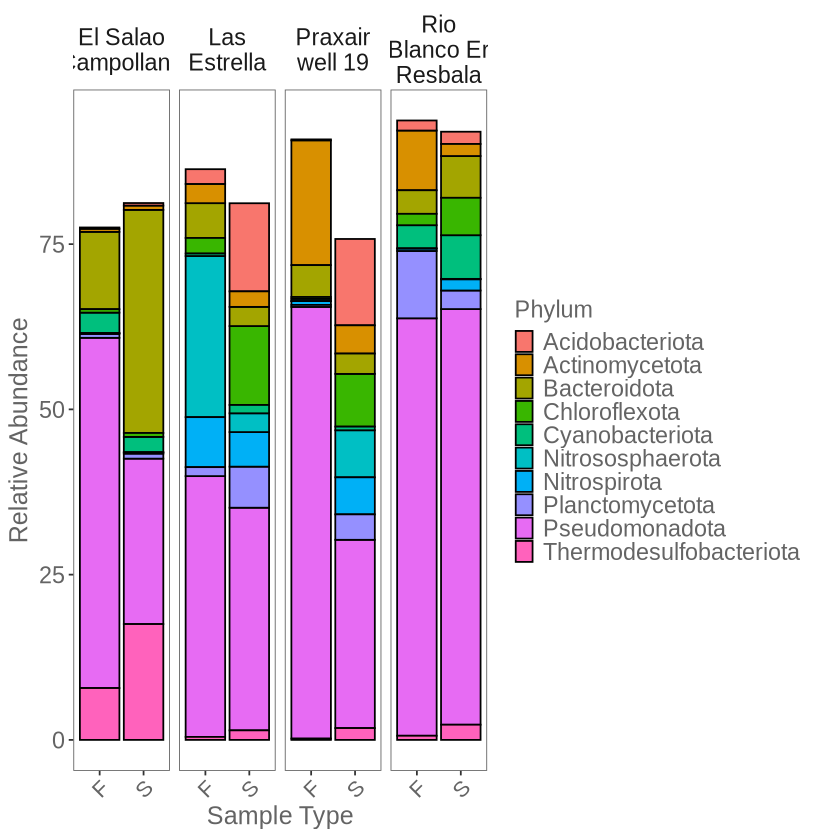

In [6]:
# ── PHYLUM ──────────────────────────────────────────────────────────────────
level <- "phylum"
payload <- read_kaiju(level)
otu <- payload$otu
taxa <- payload$taxa

phy <- phyloseq(
  otu_table(as.matrix(otu), taxa_are_rows = T),
  tax_table(as.matrix(taxa)),
  sample_data(env)
)

prok <- subset_taxa(phy, !(Kingdom %in% c("unclassified", "Viruses", "cannot be assigned to a (non-viral) phylum")))
prok_ndata_ra <- transform_sample_counts(prok, function(x) x/sum(x) * 100)

N <- 10
top10.phylum <- sort(taxa_sums(prok_ndata_ra), decreasing = TRUE)[1:N]
phylum.top10.ra <- prune_taxa(names(top10.phylum), prok_ndata_ra)

plot_bar(phylum.top10.ra, x = "Geomosaic_sample_type", fill = "Phylum") +
  facet_grid(~site_name, scales = "free", space = "free",
             labeller = labeller(site_name = label_wrap_gen(width = 10))) +
  labs(x = "Sample Type", y = "Relative Abundance") +
  theme_glab() +
  theme(
    axis.text.x       = element_text(angle = 45, vjust = 1, hjust = 1, size = 13),
    axis.text.y       = element_text(size = 14),
    axis.title        = element_text(size = 15),
    strip.text.x      = element_text(size = 14, margin = margin(t = 2, b = 2)),
    strip.text.y      = element_blank(),
    strip.background  = element_blank(),
    legend.title      = element_text(size = 14),
    legend.text       = element_text(size = 14),
    legend.position   = "right"
  )

ggsave(paste0(output_dir, "kaiju_phylum.svg"), width = 8, height = 12, dpi = 300)

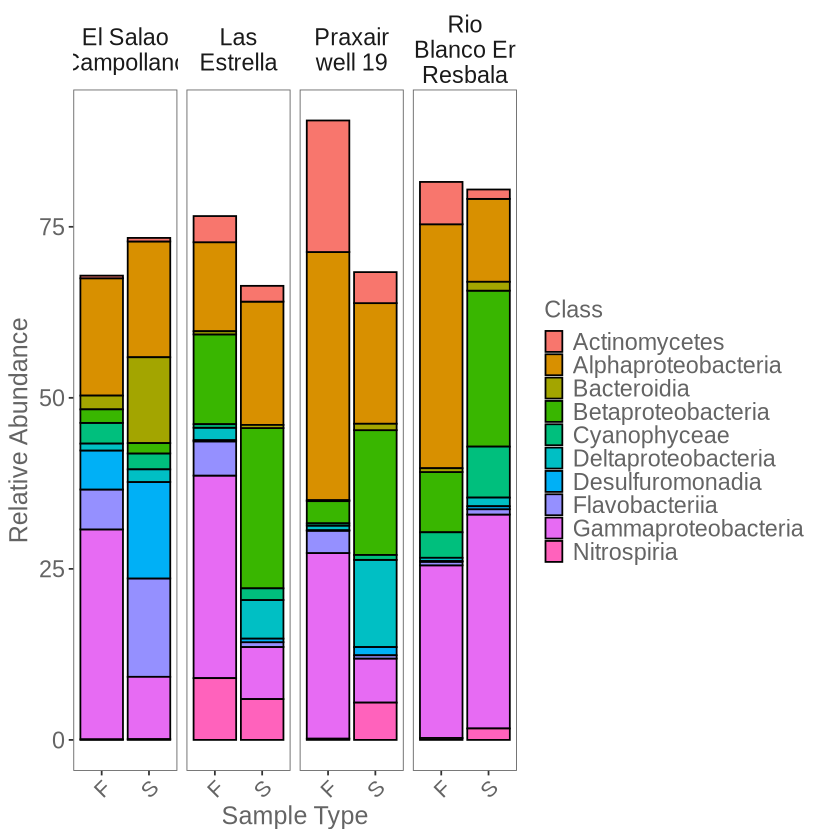

In [7]:
# ── CLASS ────────────────────────────────────────────────────────────────────
level <- "class"
payload <- read_kaiju(level)
otu <- payload$otu
taxa <- payload$taxa

phy <- phyloseq(
  otu_table(as.matrix(otu), taxa_are_rows = T),
  tax_table(as.matrix(taxa)),
  sample_data(env)
)

prok <- subset_taxa(phy, !(Kingdom %in% c("unclassified", "Viruses", "cannot be assigned to a (non-viral) class")))
prok_ndata_ra <- transform_sample_counts(prok, function(x) x/sum(x) * 100)

N <- 10
top10.class <- sort(taxa_sums(prok_ndata_ra), decreasing = TRUE)[1:N]
class.top10.ra <- prune_taxa(names(top10.class), prok_ndata_ra)

plot_bar(class.top10.ra, x = "Geomosaic_sample_type", fill = "Class") +
  facet_grid(~site_name, scales = "free", space = "free",
             labeller = labeller(site_name = label_wrap_gen(width = 10))) +
  labs(x = "Sample Type", y = "Relative Abundance") +
  theme_glab() +
  theme(
    axis.text.x       = element_text(angle = 45, vjust = 1, hjust = 1, size = 13),
    axis.text.y       = element_text(size = 14),
    axis.title        = element_text(size = 15),
    strip.text.x      = element_text(size = 14, margin = margin(t = 2, b = 2)),
    strip.text.y      = element_blank(),
    strip.background  = element_blank(),
    legend.title      = element_text(size = 14),
    legend.text       = element_text(size = 14),
    legend.position   = "right"
  )

ggsave(paste0(output_dir, "kaiju_class.svg"), width = 12, height = 8, dpi = 300)

In [8]:
kaiju_class_2 <- plot_bar(class.top10.ra, x = "Geomosaic_sample_type", fill = "Class") +
  facet_grid(~site_name, scales = "free", space = "free",
             labeller = labeller(site_name = label_wrap_gen(width = 10))) +
  labs(x = "Sample Type", y = "Relative Abundance") +
  theme_glab() +
  theme(
    axis.text.x       = element_text(angle = 45, vjust = 1, hjust = 1, size = 16),
    axis.text.y       = element_text(size = 16),
    axis.title        = element_text(size = 17),
    strip.text.x      = element_text(size = 16, margin = margin(t = 2, b = 2)),
    strip.text.y      = element_blank(),
    strip.background  = element_blank(),
    legend.title      = element_text(size = 16),
    legend.text       = element_text(size = 16),
    legend.position   = "right"
  )

ggsave(paste0(output_dir, "kaiju_class_2.svg"), width = 12, height = 8, dpi = 300)
ggsave(paste0(output_dir, "kaiju_class_2.png"), width = 12, height = 8, dpi = 300)

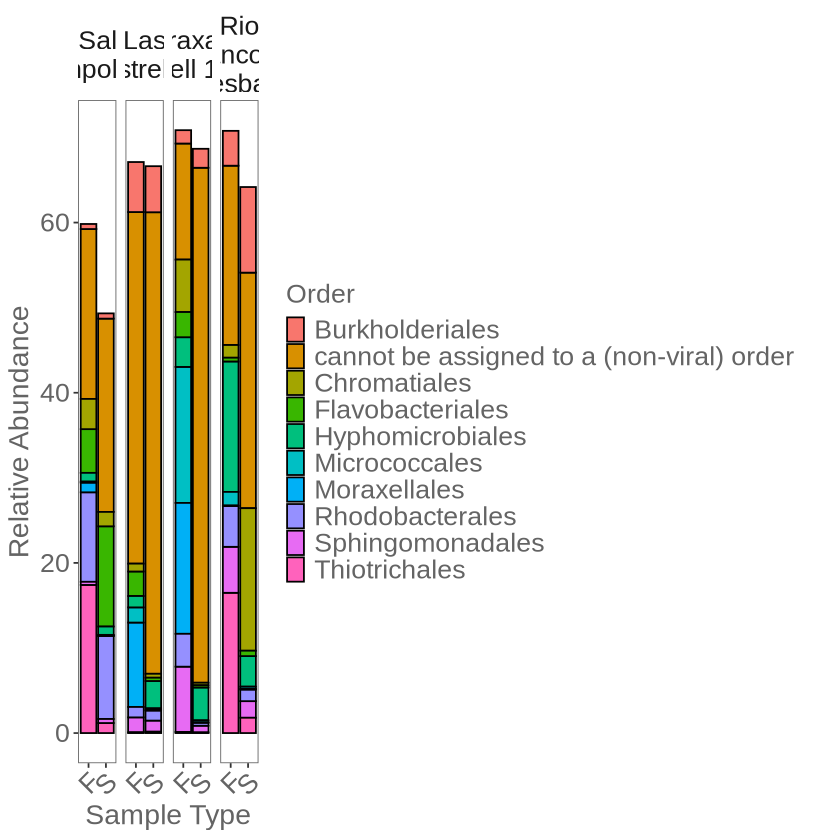

In [9]:
# ── ORDER ──────────────────────────────────────────────────────────────────
level <- "order"
payload <- read_kaiju(level)
otu <- payload$otu
taxa <- payload$taxa


# Generating Phyloseq Object
phy <- phyloseq(
  otu_table(as.matrix(otu), taxa_are_rows = T),
  tax_table(as.matrix(taxa)),
  sample_data(env)
)


prok <- subset_taxa(phy, !(Kingdom %in% c("unclassified", "Viruses", "cannot be assigned to a (non-viral) family")))
prok_ndata_ra <- transform_sample_counts(prok, function(x) x/sum(x) * 100 )

N <- 10
top10.order <- sort(taxa_sums(prok_ndata_ra), decreasing = TRUE)[1:N]
order.top10.ra <- prune_taxa(names(top10.order), prok_ndata_ra)

plot_bar(order.top10.ra, x = "Geomosaic_sample_type", fill = "Order") +
  facet_grid(~site_name, scales = "free", space = "free",
             labeller = labeller(site_name = label_wrap_gen(width = 10))) +
  labs(x = "Sample Type", y = "Relative Abundance") +
  theme_glab() +
  theme(
    axis.text.x       = element_text(angle = 45, vjust = 1, hjust = 1, size = 16),
    axis.text.y       = element_text(size = 16),
    axis.title        = element_text(size = 17),
    strip.text.x      = element_text(size = 16, margin = margin(t = 2, b = 2)),
    strip.text.y      = element_blank(),
    strip.background  = element_blank(),
    legend.title      = element_text(size = 16),
    legend.text       = element_text(size = 16),
    legend.position   = "right"
  )

ggsave(paste0(output_dir, "kaiju_order.svg"), width = 12, height = 8, dpi = 300)


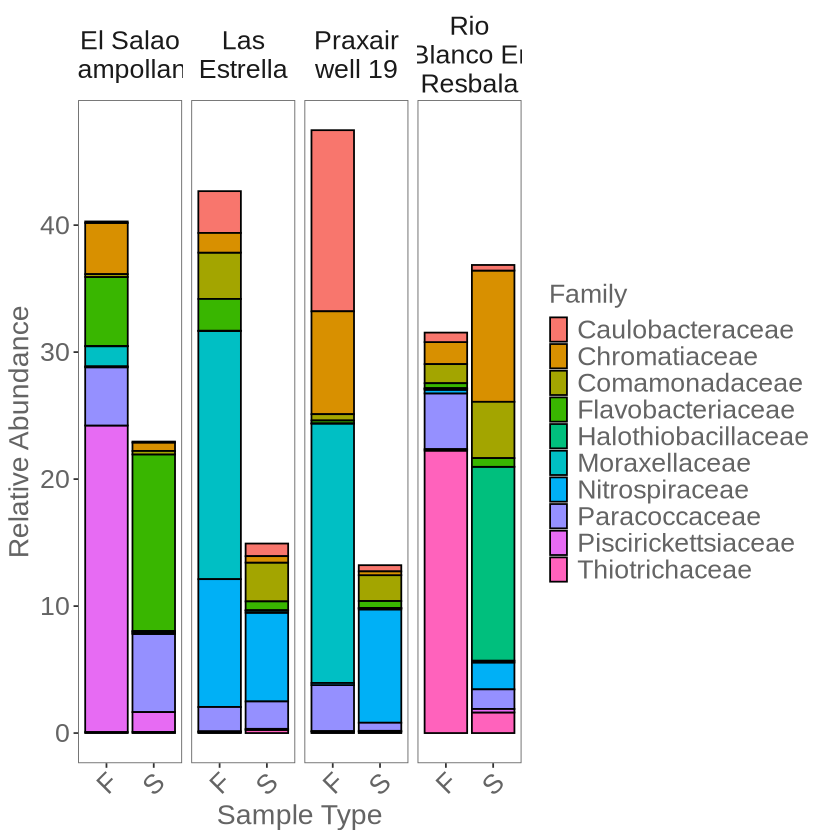

In [10]:
# ── FAMILY ───────────────────────────────────────────────────────────────────
level <- "family"
payload <- read_kaiju(level)
otu <- payload$otu
taxa <- payload$taxa

phy <- phyloseq(
  otu_table(as.matrix(otu), taxa_are_rows = T),
  tax_table(as.matrix(taxa)),
  sample_data(env)
)

prok <- subset_taxa(phy, !(Kingdom %in% c("unclassified", "Viruses", "cannot be assigned to a (non-viral) family")))
prok_ndata_ra <- transform_sample_counts(prok, function(x) x/sum(x) * 100)

N <- 10
top10.family <- sort(taxa_sums(prok_ndata_ra), decreasing = TRUE)[1:N]
family.top10.ra <- prune_taxa(names(top10.family), prok_ndata_ra)

plot_bar(family.top10.ra, x = "Geomosaic_sample_type", fill = "Family") +
  facet_grid(~site_name, scales = "free", space = "free",
             labeller = labeller(site_name = label_wrap_gen(width = 10))) +
  labs(x = "Sample Type", y = "Relative Abundance") +
  theme_glab() +
  theme(
    axis.text.x       = element_text(angle = 45, vjust = 1, hjust = 1, size = 16),
    axis.text.y       = element_text(size = 16),
    axis.title        = element_text(size = 17),
    strip.text.x      = element_text(size = 16, margin = margin(t = 2, b = 2)),
    strip.text.y      = element_blank(),
    strip.background  = element_blank(),
    legend.title      = element_text(size = 16),
    legend.text       = element_text(size = 16),
    legend.position   = "right"
  )

  ggsave(paste0(output_dir,  "kaiju_family.svg"), width = 12, height = 8, dpi = 300)

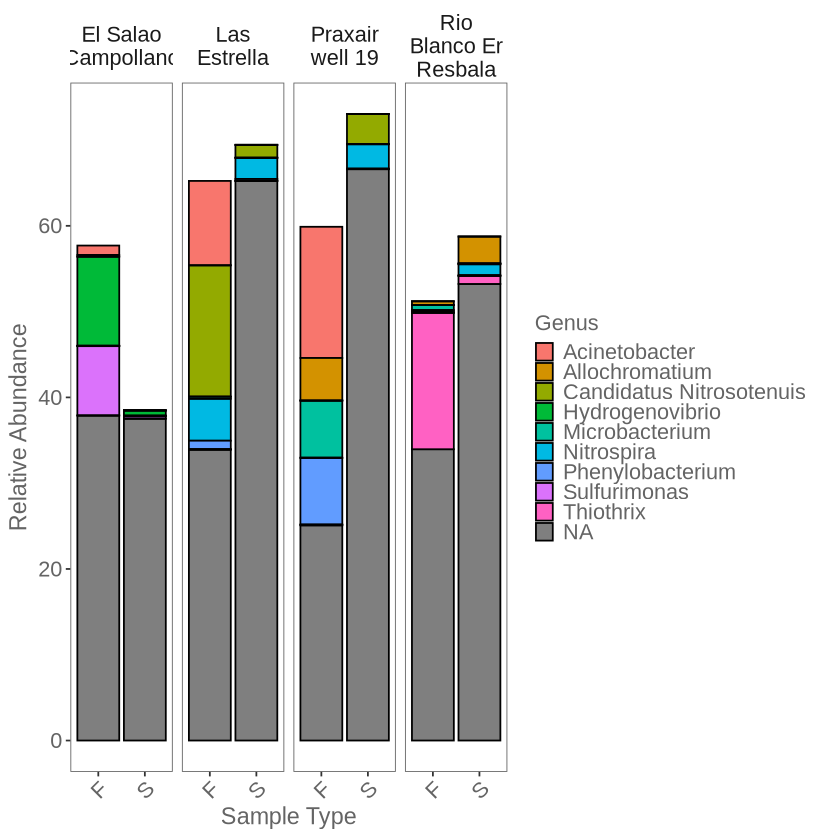

In [11]:
# ── GENUS ──────────────────────────────────────────────────────────────────
level <- "genus"
payload <- read_kaiju(level)
otu <- payload$otu
taxa <- payload$taxa

phy <- phyloseq(
  otu_table(as.matrix(otu), taxa_are_rows = T),
  tax_table(as.matrix(taxa)),
  sample_data(env)
)

prok <- subset_taxa(phy, !(Kingdom %in% c("unclassified", "Viruses", "cannot be assigned to a (non-viral) species")))
prok_ndata_ra <- transform_sample_counts(prok, function(x) x/sum(x) * 100)

N <- 10
top10.genus <- sort(taxa_sums(prok_ndata_ra), decreasing = TRUE)[1:N]
genus.top10.ra <- prune_taxa(names(top10.genus), prok_ndata_ra)

plot_bar(genus.top10.ra, x = "Geomosaic_sample_type", fill = "Genus") +
  facet_grid(~site_name, scales = "free", space = "free",
             labeller = labeller(site_name = label_wrap_gen(width = 10))) +
  labs(x = "Sample Type", y = "Relative Abundance") +
  theme_glab() +
 theme(
    axis.text.x       = element_text(angle = 45, vjust = 1, hjust = 1, size = 13),
    axis.text.y       = element_text(size = 13),
    axis.title        = element_text(size = 14),
    strip.text.x      = element_text(size = 13, margin = margin(t = 2, b = 2)),
    strip.text.y      = element_blank(),
    strip.background  = element_blank(),
    legend.title      = element_text(size = 13),
    legend.text       = element_text(size = 13),
    legend.position   = "right"
  )

ggsave(paste0(output_dir, "kaiju_genus.svg"), width = 12, height = 8, dpi = 300)

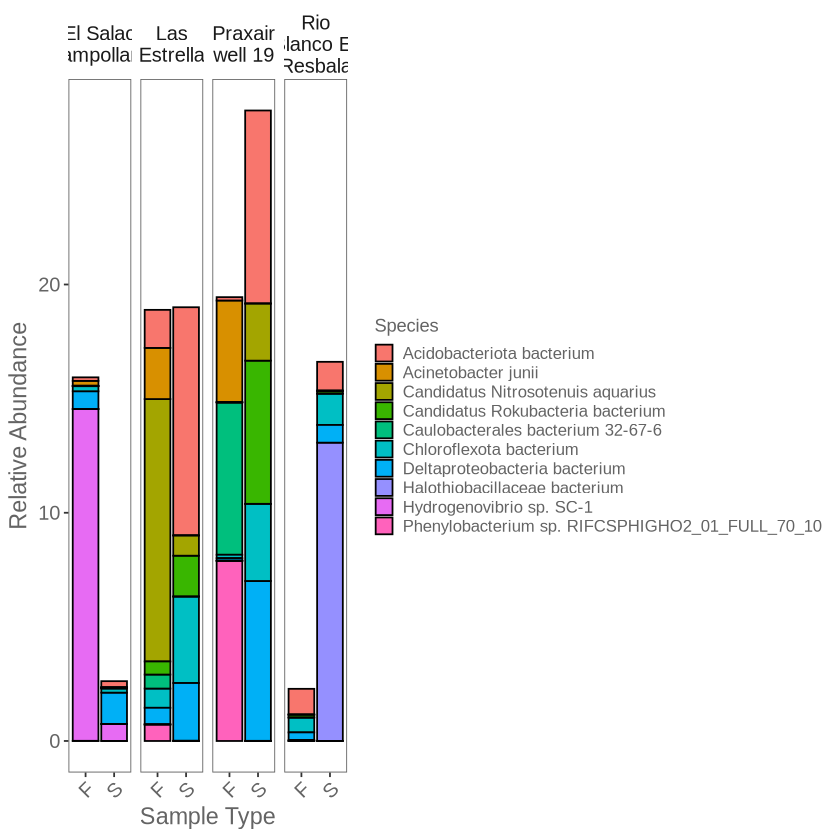

In [12]:
# ── SPECIES ──────────────────────────────────────────────────────────────────
level <- "species"
payload <- read_kaiju(level)
otu <- payload$otu
taxa <- payload$taxa

phy <- phyloseq(
  otu_table(as.matrix(otu), taxa_are_rows = T),
  tax_table(as.matrix(taxa)),
  sample_data(env)
)

prok <- subset_taxa(phy, !(Kingdom %in% c("unclassified", "Viruses", "cannot be assigned to a (non-viral) species")))
prok_ndata_ra <- transform_sample_counts(prok, function(x) x/sum(x) * 100)

N <- 10
top10.species <- sort(taxa_sums(prok_ndata_ra), decreasing = TRUE)[1:N]
species.top10.ra <- prune_taxa(names(top10.species), prok_ndata_ra)

plot_bar(species.top10.ra, x = "Geomosaic_sample_type", fill = "Species") +
  facet_grid(~site_name, scales = "free", space = "free",
             labeller = labeller(site_name = label_wrap_gen(width = 10))) +
  labs(x = "Sample Type", y = "Relative Abundance") +
  theme_glab() +
  theme(
    axis.text.x       = element_text(angle = 45, vjust = 1, hjust = 1, size = 12),
    axis.text.y       = element_text(size = 12),
    axis.title        = element_text(size = 14),
    strip.text.x      = element_text(size = 12, margin = margin(t = 2, b = 2)),
    strip.text.y      = element_blank(),
    strip.background  = element_blank(),
    legend.title      = element_text(size = 11),
    legend.text       = element_text(size = 10),
    legend.position   = "right"
  )

ggsave(paste0(output_dir, "kaiju_species.svg"), width = 12, height = 8, dpi = 300)

In [13]:
# ── NMDS ─────────────────────────────────────────────────────────────────────

# Normalise counts (median-ratio scaling)
prok_ndata <- transform_sample_counts(
  prok,
  function(x) (x / sum(x)) * median(microbiome::readcount(prok))
)

# Glom at Family and convert to relative abundance
prok_nmds <- prok_ndata %>%
  tax_glom("Family") %>%
  transform_sample_counts(function(x) x / sum(x))

# Weighted Bray-Curtis
nmds_w  <- distance(prok_nmds, method = "bray")
ord_w   <- ordinate(prok_nmds, nmds_w,  method = "NMDS", trymax = 1000)

# Unweighted (binary) Bray-Curtis
nmds_uw <- distance(prok_nmds, method = "bray", binary = TRUE)
ord_uw  <- ordinate(prok_nmds, nmds_uw, method = "NMDS", trymax = 1000)


Run 0 stress 0.04940863 
Run 1 stress 0.04940863 
... Procrustes: rmse 1.120478e-05  max resid 2.098202e-05 
... Similar to previous best
Run 2 stress 0.04940863 
... Procrustes: rmse 8.355865e-06  max resid 1.342677e-05 
... Similar to previous best
Run 3 stress 0.04940863 
... New best solution
... Procrustes: rmse 1.788163e-06  max resid 2.928819e-06 
... Similar to previous best
Run 4 stress 0.04940863 
... Procrustes: rmse 2.245544e-06  max resid 4.20209e-06 
... Similar to previous best
Run 5 stress 0.04940863 
... New best solution
... Procrustes: rmse 8.729906e-07  max resid 1.409409e-06 
... Similar to previous best
Run 6 stress 0.04940863 
... Procrustes: rmse 1.091219e-05  max resid 1.849085e-05 
... Similar to previous best
Run 7 stress 0.0893341 
Run 8 stress 0.04940863 
... Procrustes: rmse 1.703733e-06  max resid 3.641327e-06 
... Similar to previous best
Run 9 stress 0.1044081 
Run 10 stress 0.04940863 
... Procrustes: rmse 5.48809e-06  max resid 9.56219e-06 
... Simila

In [14]:

# --- Palette fissa per i biomi ---
biome_colors <- c(
"#cab2d6",
"#1F78B4",  # blu
"#e31a1c",
"#33a02c"  # verde
)


# Plot weighted
nmds_weighted <- plot_ordination(
  prok_nmds, ord_w,
  type  = "samples",
  #title = paste0("NMDS Weighted Bray-Curtis | Stress: ", round(ord_w$stress, 3)),
  #color = "site_name"          # ← match exactly your sample_data column name
) +
  geom_point(
    aes(fill = site_name),      # ← mapped: fill by the site_name column
    shape  = 21,                 # ← fixed: circle with fill + outline
    color  = "black",            # ← fixed: outline color
    stroke = 1,                  # ← fixed: outline thickness
    size   = 8                   # ← fixed: point size
  ) +
  scale_fill_manual(values = biome_colors) +   # ← palette applied here, as its own layer
  labs(fill = "Sampling Site") +               # ← use fill, not color, since fill is now the mapped legend
  theme_glab() +
  theme(
    #plot.title        = element_text(size = 17, face = "bold"),
    axis.text.x       = element_text(angle = 45, vjust = 1, hjust = 1, size = 16),
    axis.text.y       = element_text(size = 16),
    axis.title        = element_text(size = 15),
    strip.text.x      = element_text(size = 16, margin = margin(t = 2, b = 2)),
    strip.text.y      = element_blank(),
    strip.background  = element_blank(),
    legend.title      = element_text(size = 16),
    legend.text       = element_text(size = 16),
    legend.position   = "right"
  )
ggsave(paste0(output_dir, "nmds_weighted.svg"), width = 8, height = 12, dpi = 300)
# Plot unweighted
nmds_unweighted <- plot_ordination(
  prok_nmds, ord_uw,
  type  = "samples",
  title = paste0("NMDS Unweighted Bray-Curtis | Stress: ", round(ord_uw$stress, 3)),
  color = "site_name"
) +
scale_color_manual(values = biome_colors) +
geom_point(
    shape = 21,
    color = "black",
    stroke = 1,
    size = 8
) +
labs(color = "Sampling Site") +  # ← ADD THIS LINE WITH YOUR CUSTOM TITLE
theme_glab() +
theme(
    plot.title        = element_text(size = 14, face = "bold", hjust = 0.5),
    axis.text.x       = element_text(angle = 45, vjust = 1, hjust = 1, size = 12),
    axis.text.y       = element_text(size = 12),
    axis.title        = element_text(size = 14),
    strip.text.x      = element_text(size = 12, margin = margin(t = 2, b = 2)),
    strip.text.y      = element_blank(),
    strip.background  = element_blank(),
    legend.title      = element_text(size = 14),
    legend.text       = element_text(size = 13),
    legend.position   = "right"
  )
ggsave(paste0(output_dir, "nmds_unweighted.svg"), width = 8, height = 12, dpi = 300)

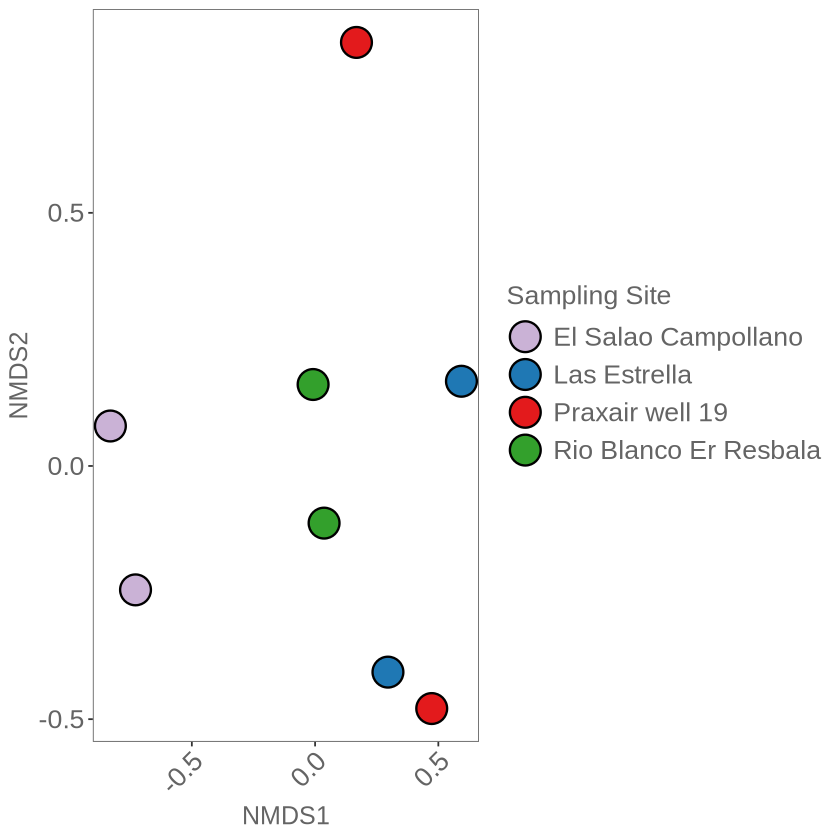

In [15]:
nmds_weighted

In [16]:
#options(rep.plot.width=20)
#options(rep.plot.height=20)

In [17]:
options(repr.plot.width = 18, repr.plot.height = 8)

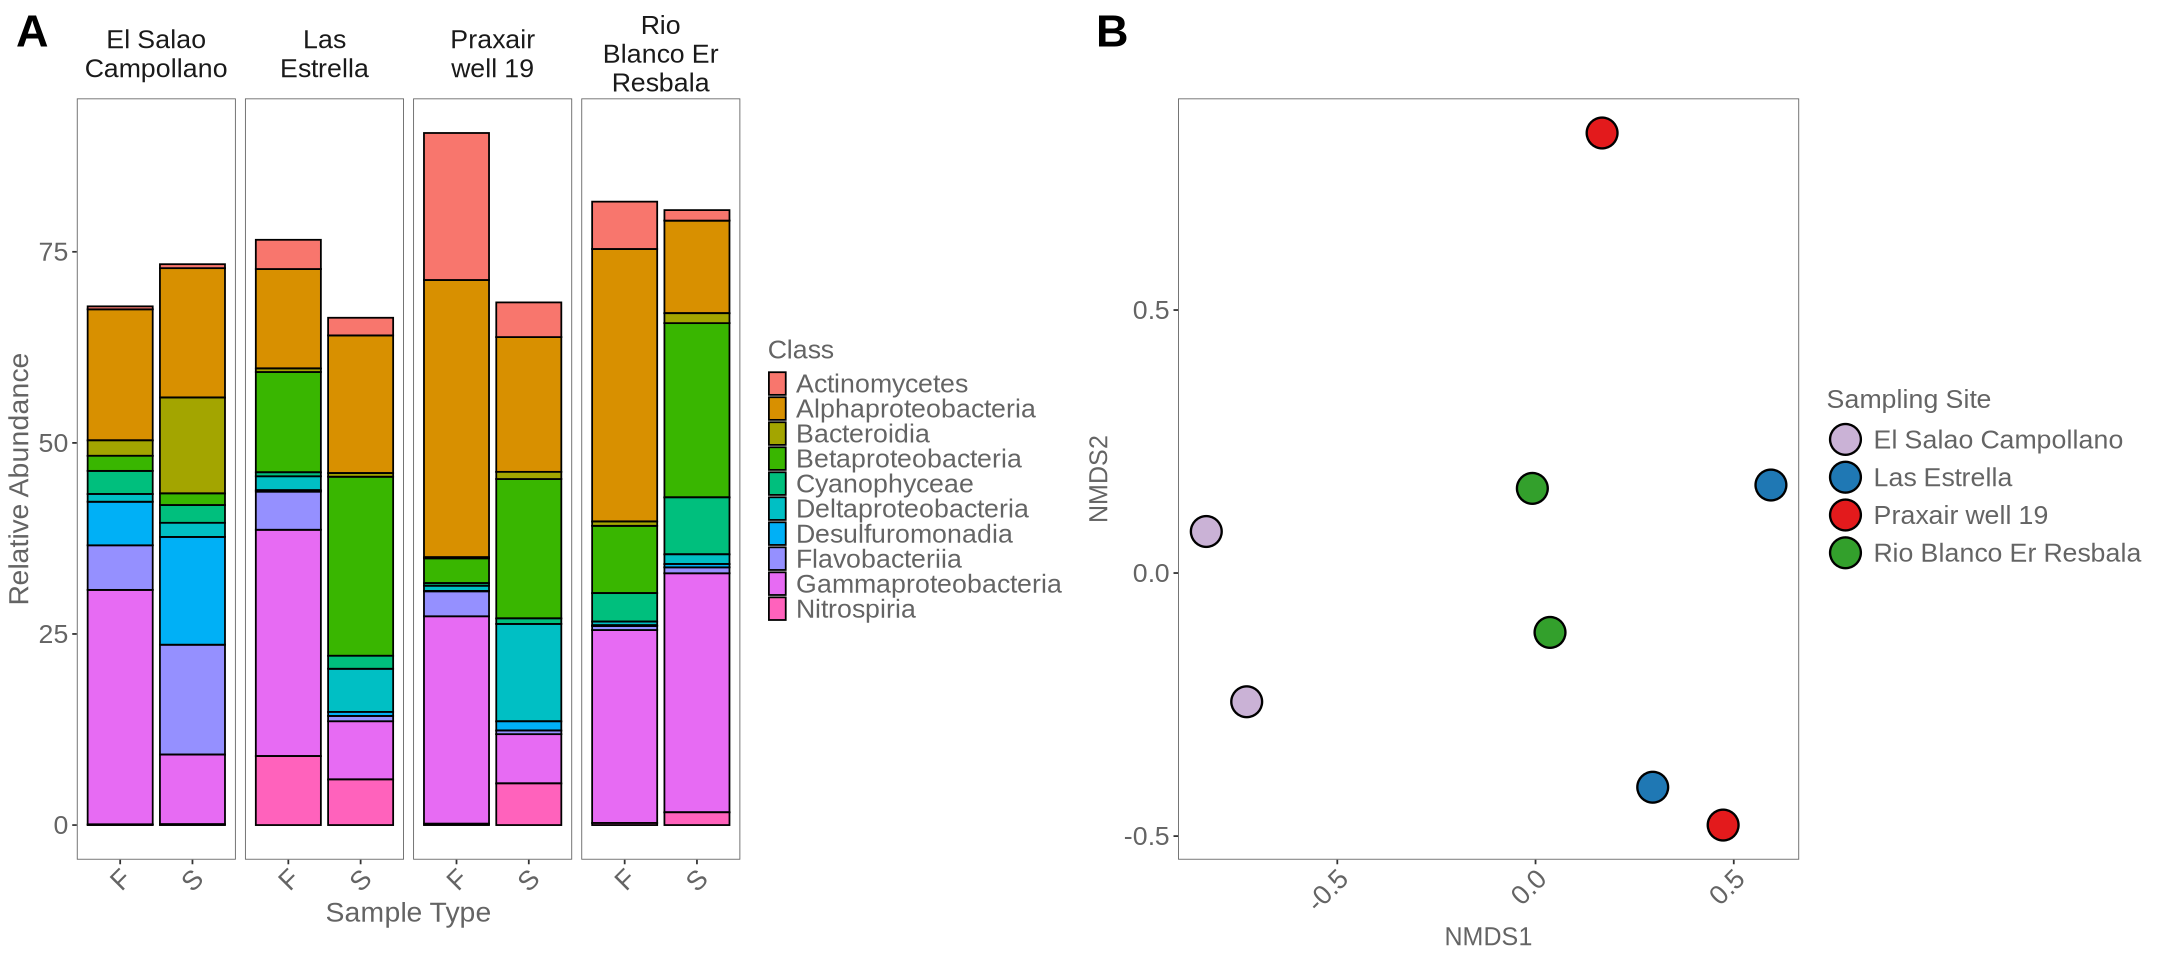

In [18]:


top_row <- plot_grid(
  kaiju_class_2, nmds_weighted,
  labels      = c("A", "B"), 
  label_size = 27,
  ncol        = 2,             # side by side; use nrow = 2 to stack vertically
  align       = "h",           # align horizontally (top/bottom edges)
  axis        = "tb",
  rel_widths  = c(1, 1)      # barplot is wider (facets) than NMDS, adjust to taste
)
top_row
ggsave(paste0(output_dir, "combined_plot_figure_3.png"), width = 18, height = 8, dpi = 300)
ggsave(paste0(output_dir, "combined_plot_figure_3.svg"), width = 18, height = 8, dpi = 300)

In [19]:
library(png)
library(grid)
kegg_decoder_subset <- readPNG("../tables/heatmap_variance_category.png")
kegg_decoder_v <- as_ggplot(rasterGrob(kegg_decoder_subset, interpolate = TRUE))

ERROR: Error in as_ggplot(rasterGrob(kegg_decoder_subset, interpolate = TRUE)): could not find function "as_ggplot"


In [ ]:
options(repr.plot.width = 16, repr.plot.height = 12)

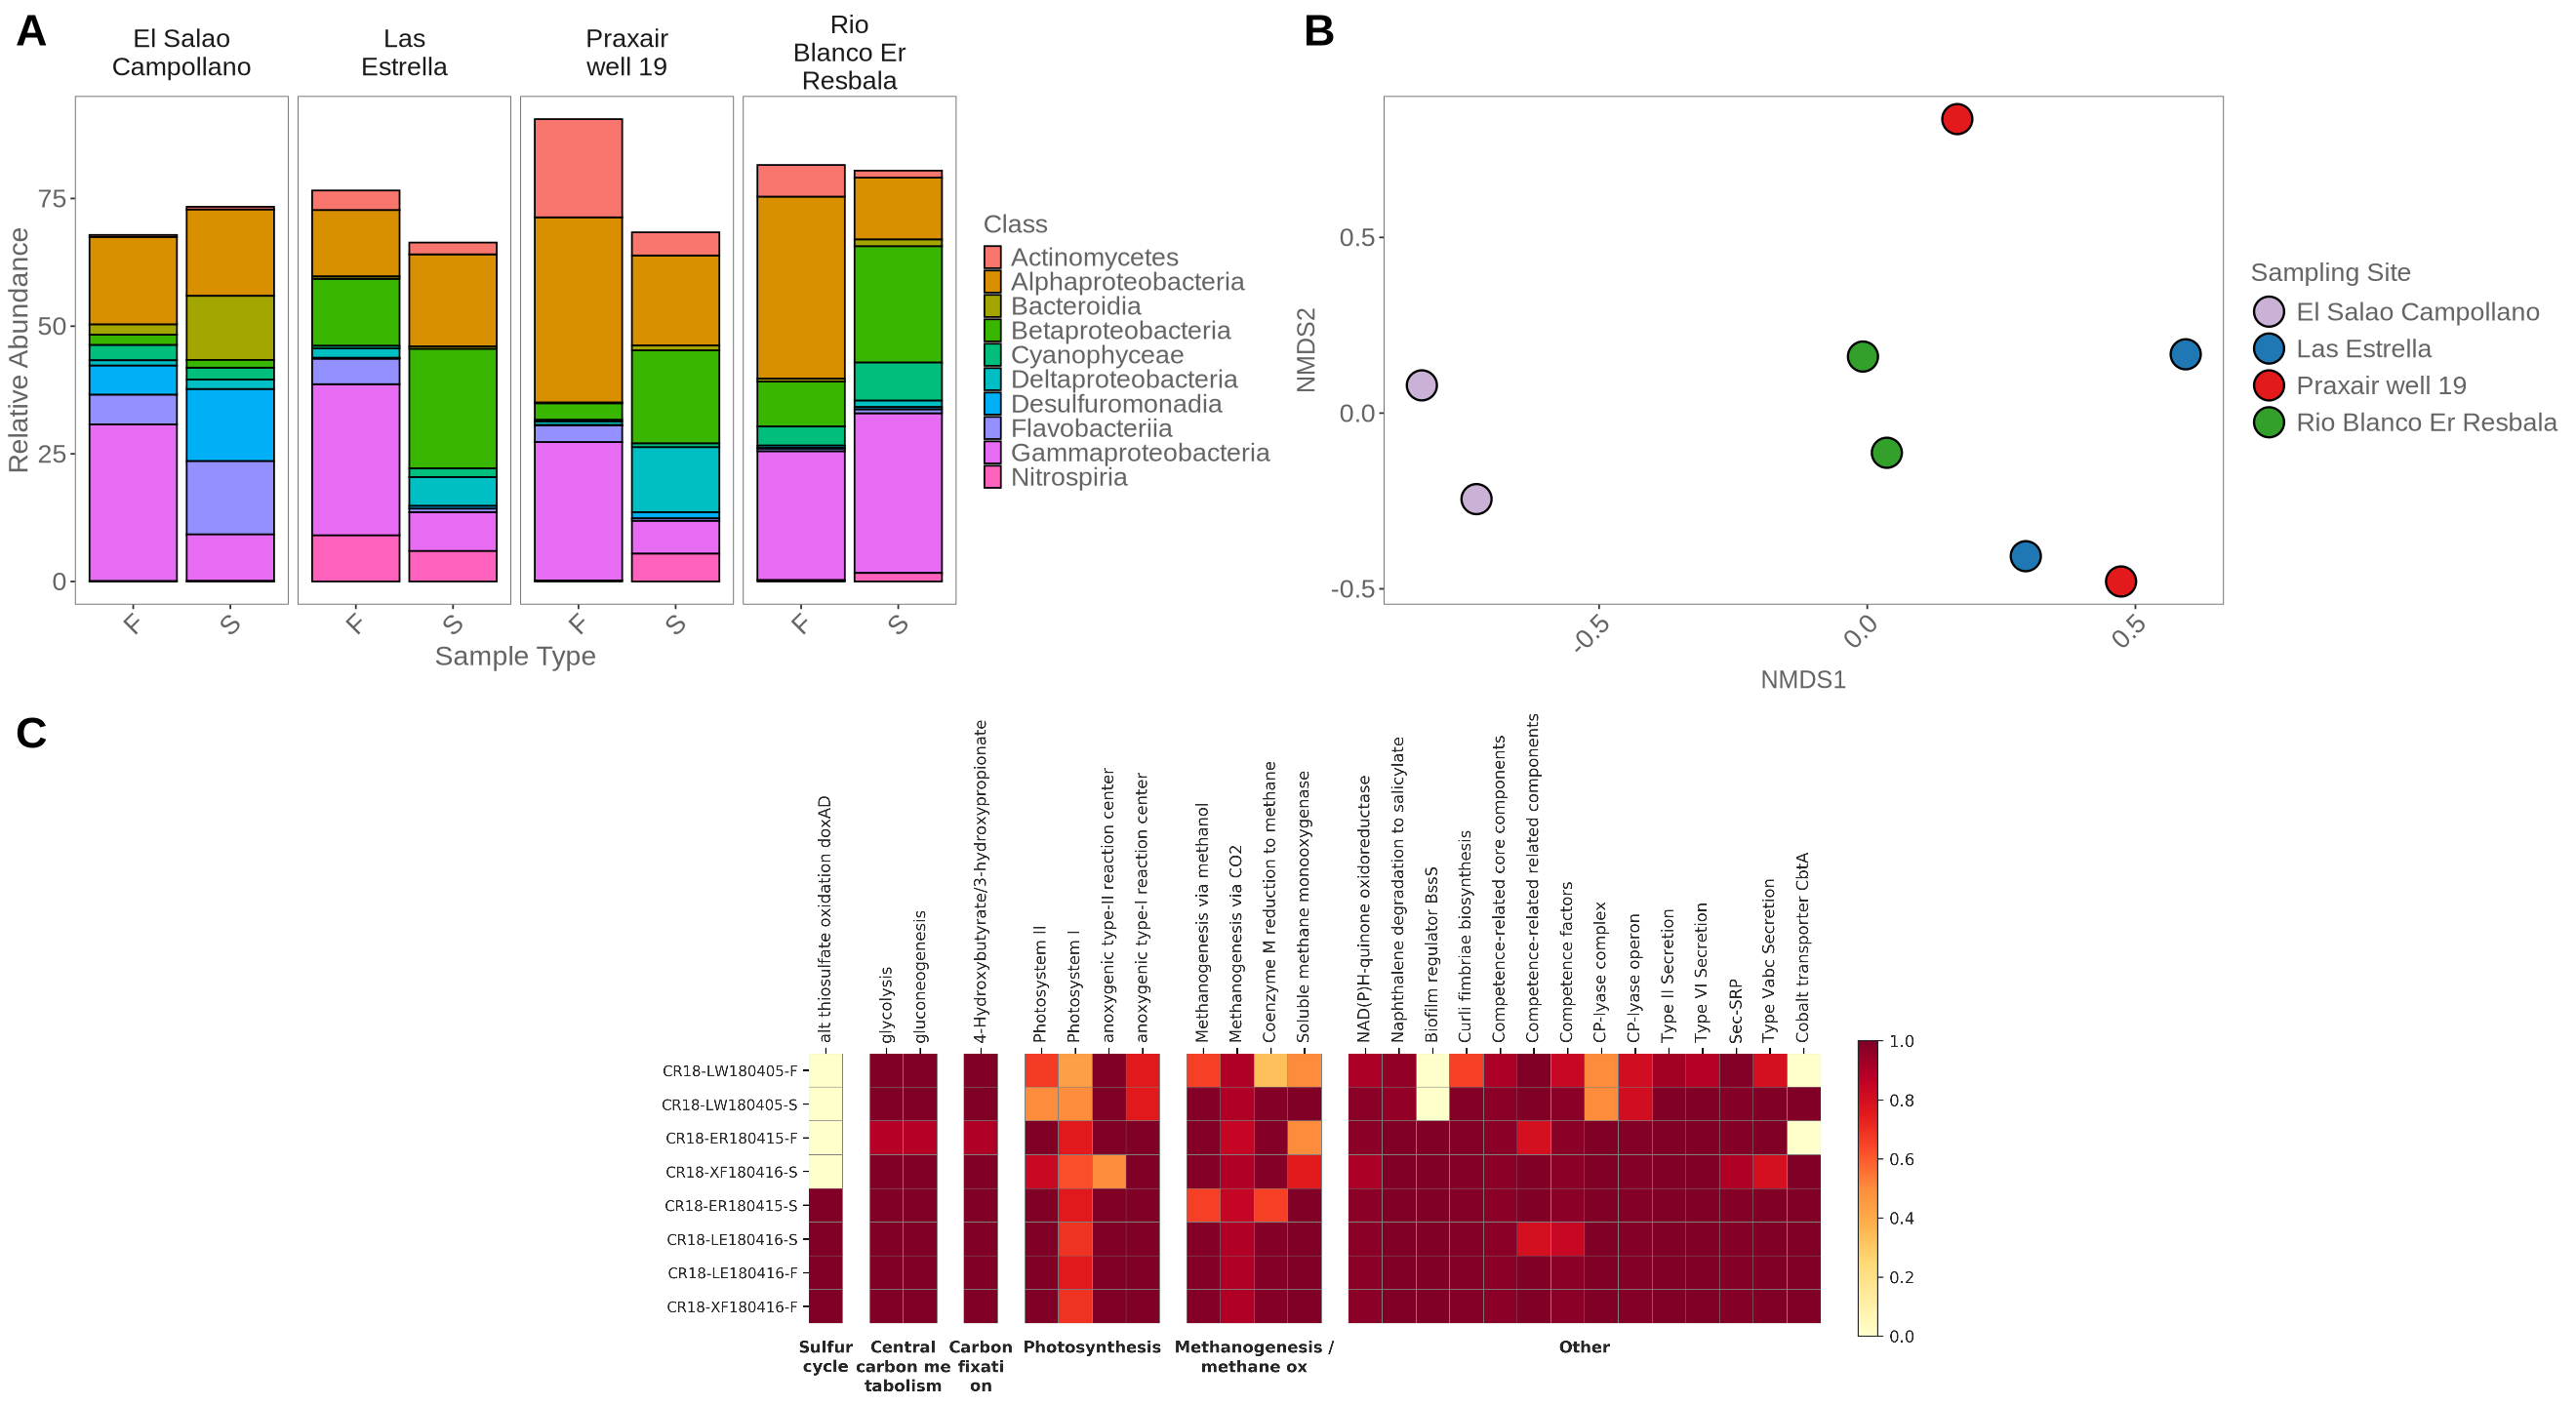

In [ ]:
# Step 2: stack the top row with panel C underneath
combined_plot_v <- plot_grid(
  top_row, kegg_decoder_v,
  labels      = c("", "C"),   # A/B labels already applied in top_rowoptions(repr.plot.width = 10, repr.plot.height = 22)
  label_size  = 27,
  ncol        = 1,
  align       = "h",           # align vertically (top/bottom edges)
  rel_heights = c(1, 1),
  rel_widths = c(1, 1)      # adjust ratio: how wide the heatmap is vs A+B row
)

combined_plot_v
ggsave(paste0(output_dir, "combined_plot_figure3.png"), width = 14, height = 16, dpi = 300)
ggsave(paste0(output_dir, "combined_plot_figure3.svg"), width = 14, height = 16 , dpi = 300)

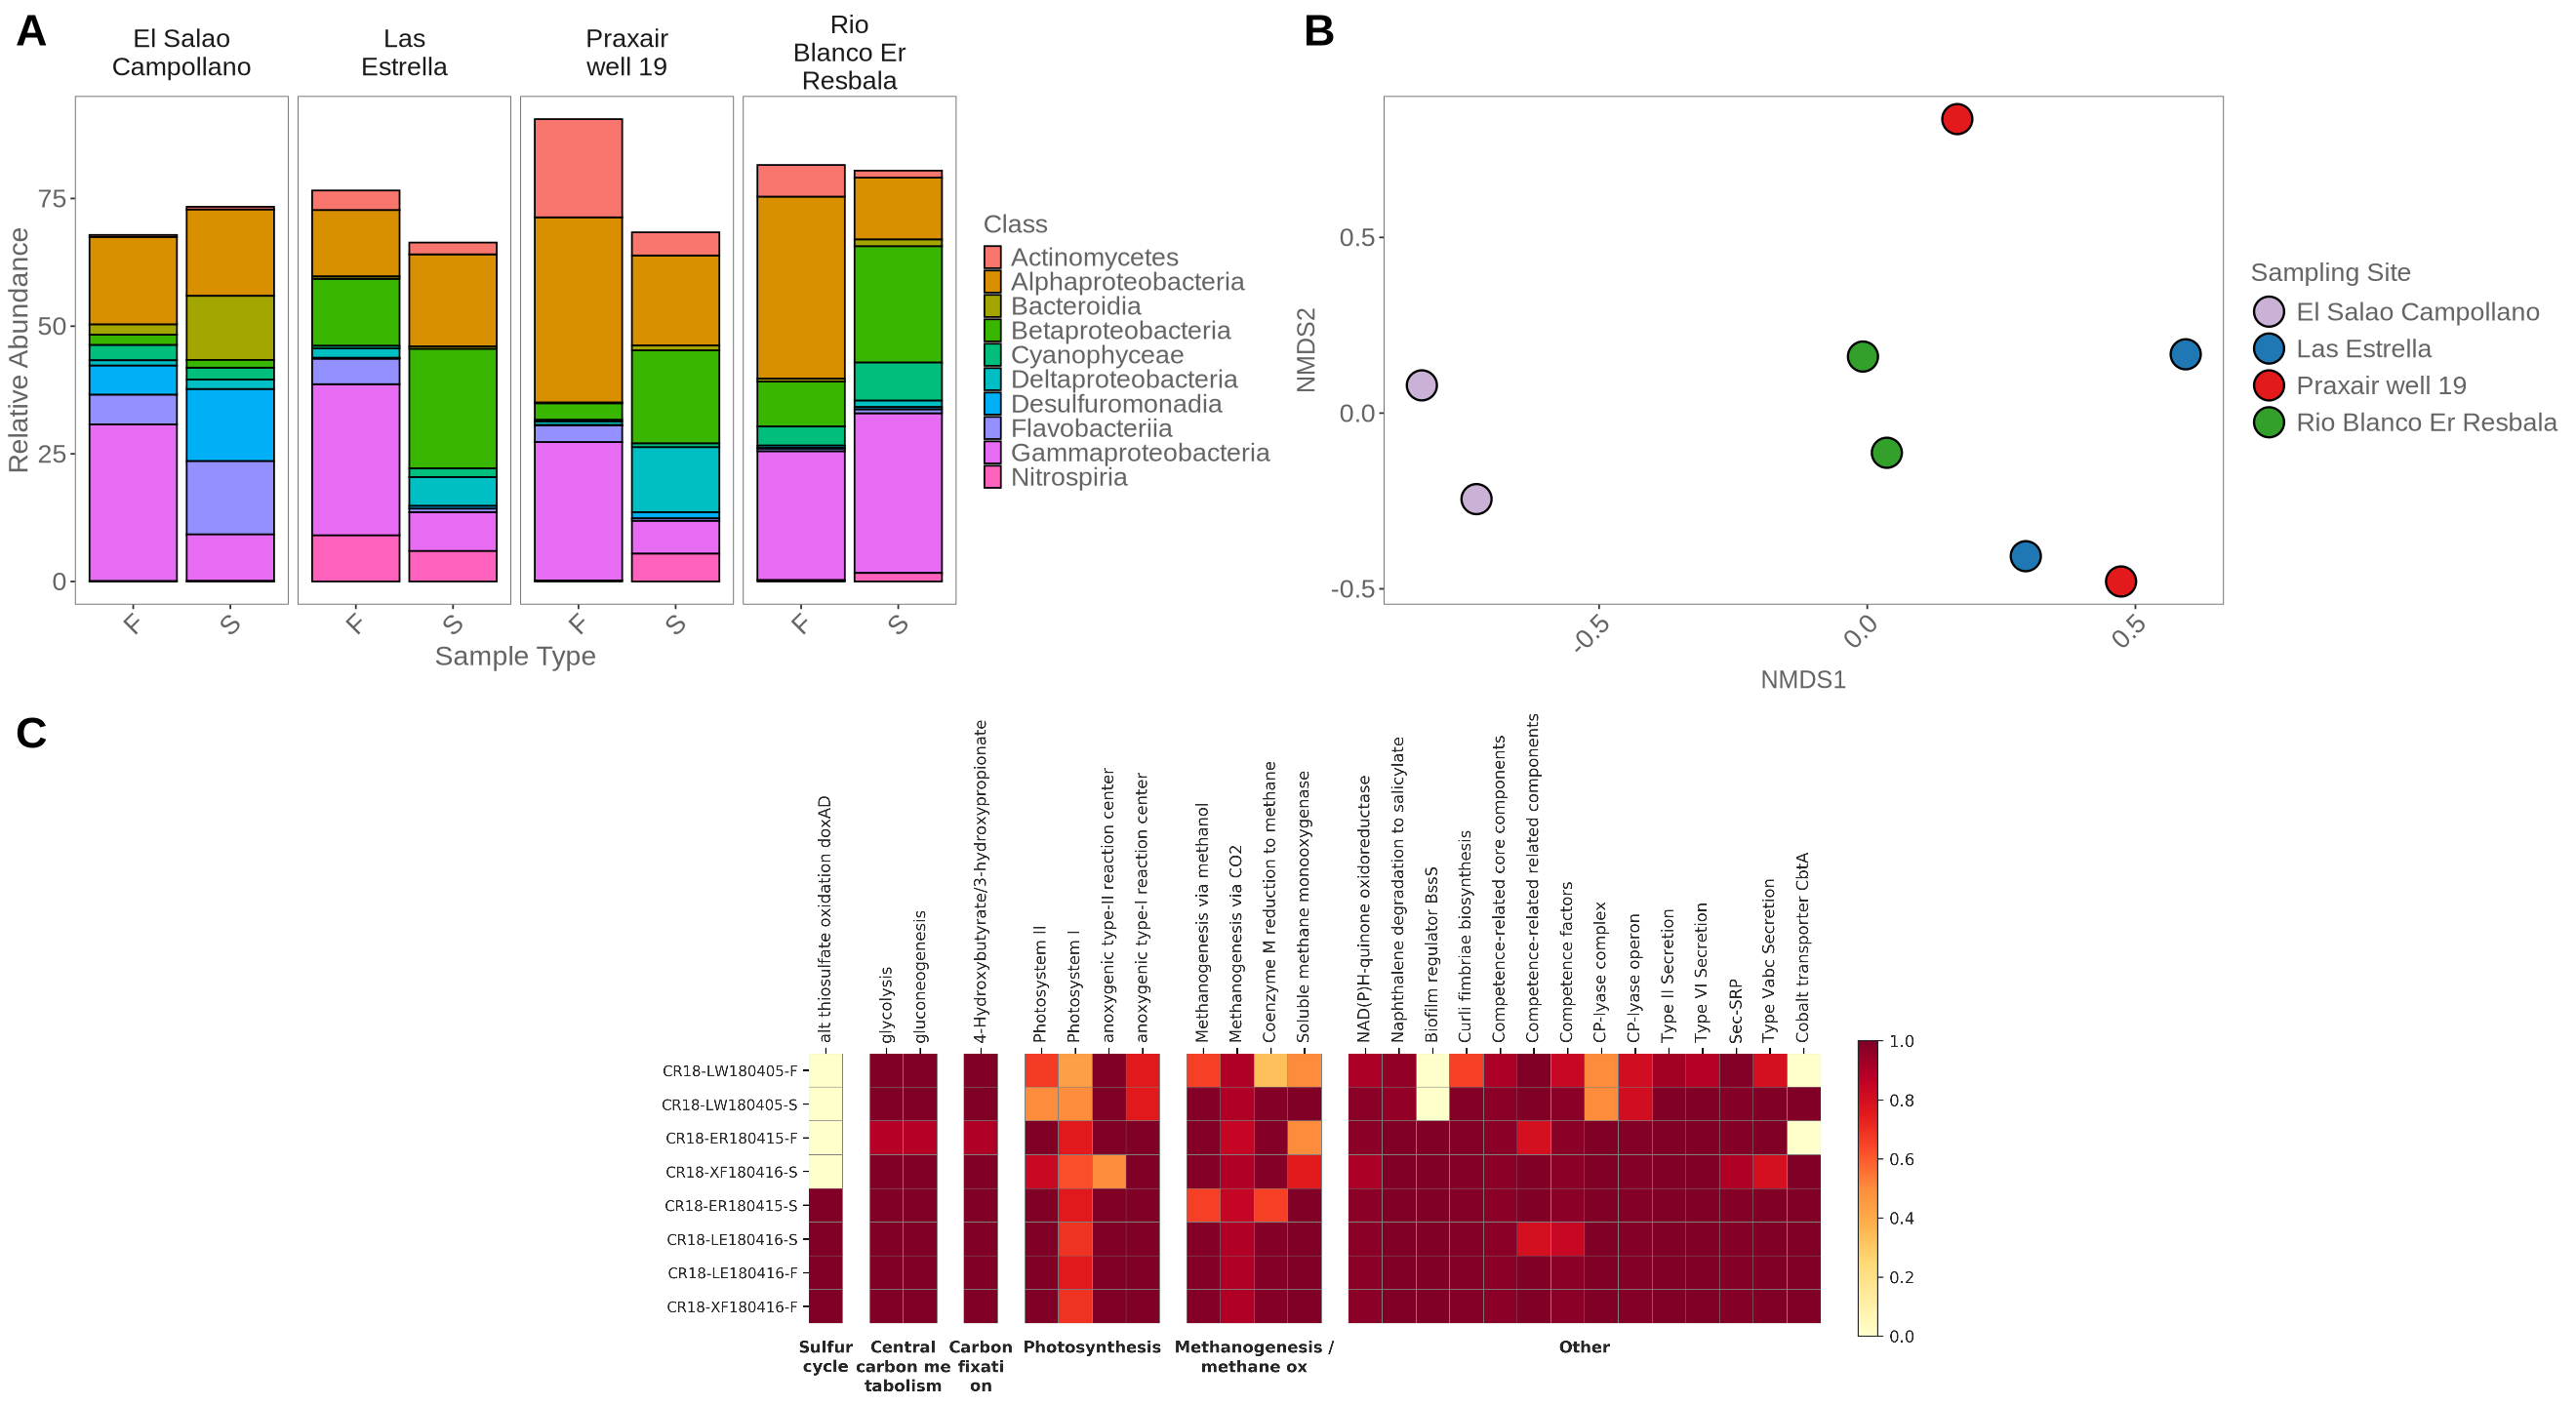

In [ ]:
# Step 2: stack the top row with panel C underneath
combined_plot_v <- plot_grid(
  top_row, kegg_decoder_v,
  labels      = c("", "C"),   # A/B labels already applied in top_rowoptions(repr.plot.width = 10, repr.plot.height = 22)
  label_size  = 27,
  ncol        = 1,
  align       = "h",           # align vertically (top/bottom edges)
  rel_heights = c(1, 1),
  rel_widths = c(1, 1)      # adjust ratio: how wide the heatmap is vs A+B row
)

combined_plot_v
ggsave(paste0(output_dir, "combined_plot_figure3_1.png"), width = 18, height = 16, dpi = 300)
ggsave(paste0(output_dir, "combined_plot_figure3_1.svg"), width = 18, height = 16 , dpi = 300)

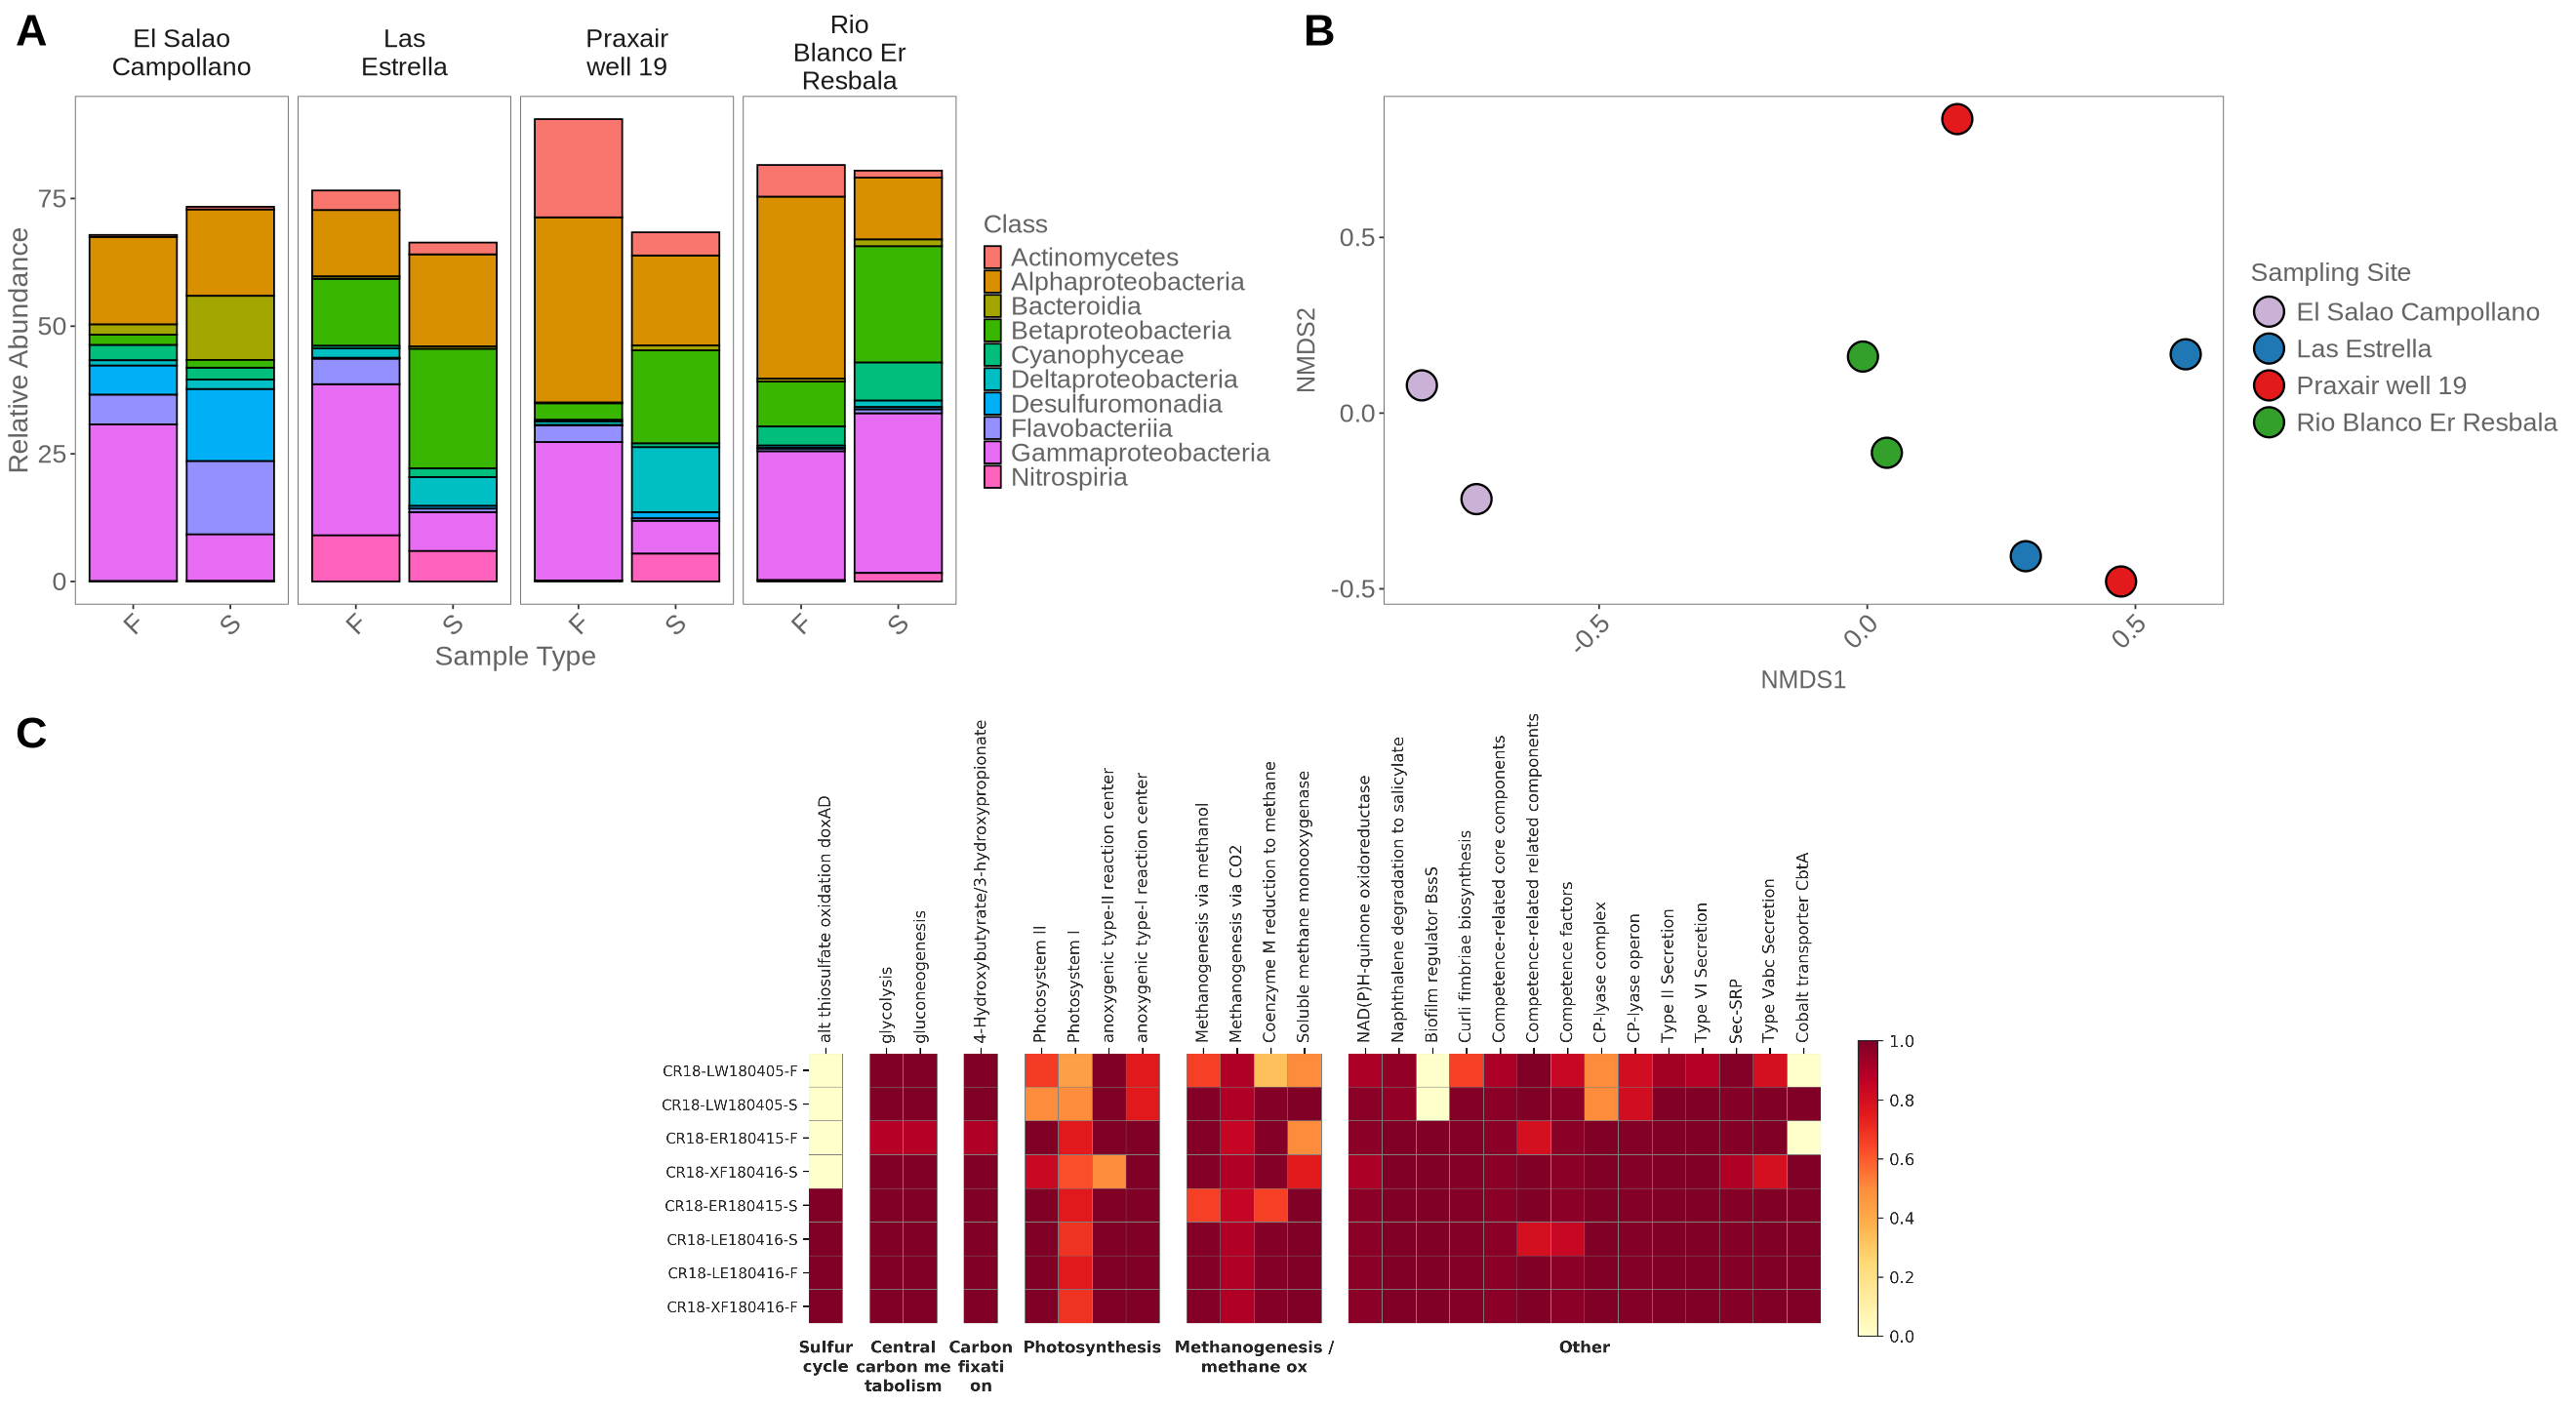

In [ ]:
# Step 2: stack the top row with panel C underneath
combined_plot_v <- plot_grid(
  top_row, kegg_decoder_v,
  labels      = c("", "C"),   # A/B labels already applied in top_rowoptions(repr.plot.width = 10, repr.plot.height = 22)
  label_size  = 27,
  ncol        = 1,
  align       = "h",           # align vertically (top/bottom edges)
  rel_heights = c(1, 1),
  rel_widths = c(1, 1)      # adjust ratio: how wide the heatmap is vs A+B row
)

combined_plot_v
ggsave(paste0(output_dir, "combined_plot_figure3.2.png"), width = 18, height = 12, dpi = 300)
ggsave(paste0(output_dir, "combined_plot_figure3.2.svg"), width = 18, height = 12 , dpi = 300)

In [ ]:
# Step 2: stack the top row with panel C underneath
combined_plot_v <- plot_grid(
  top_row, kegg_decoder_v,
  labels      = c("", "C"),   # A/B labels already applied in top_rowoptions(repr.plot.width = 10, repr.plot.height = 22)
  label_size  = 27,
  ncol        = 1,
  align       = "h",           # align vertically (top/bottom edges)
  rel_heights = c(1, 1),
  rel_widths = c(1, 1)      # adjust ratio: how wide the heatmap is vs A+B row
)

combined_plot_v
ggsave(paste0(output_dir, "combined_plot_figure3.3.png"), width = 18, height = 12, dpi = 300)
ggsave(paste0(output_dir, "combined_plot_figure3.3.svg"), width = 18, height = 12 , dpi = 300)

In [ ]:
options(repr.plot.width = 10, repr.plot.height = 22)

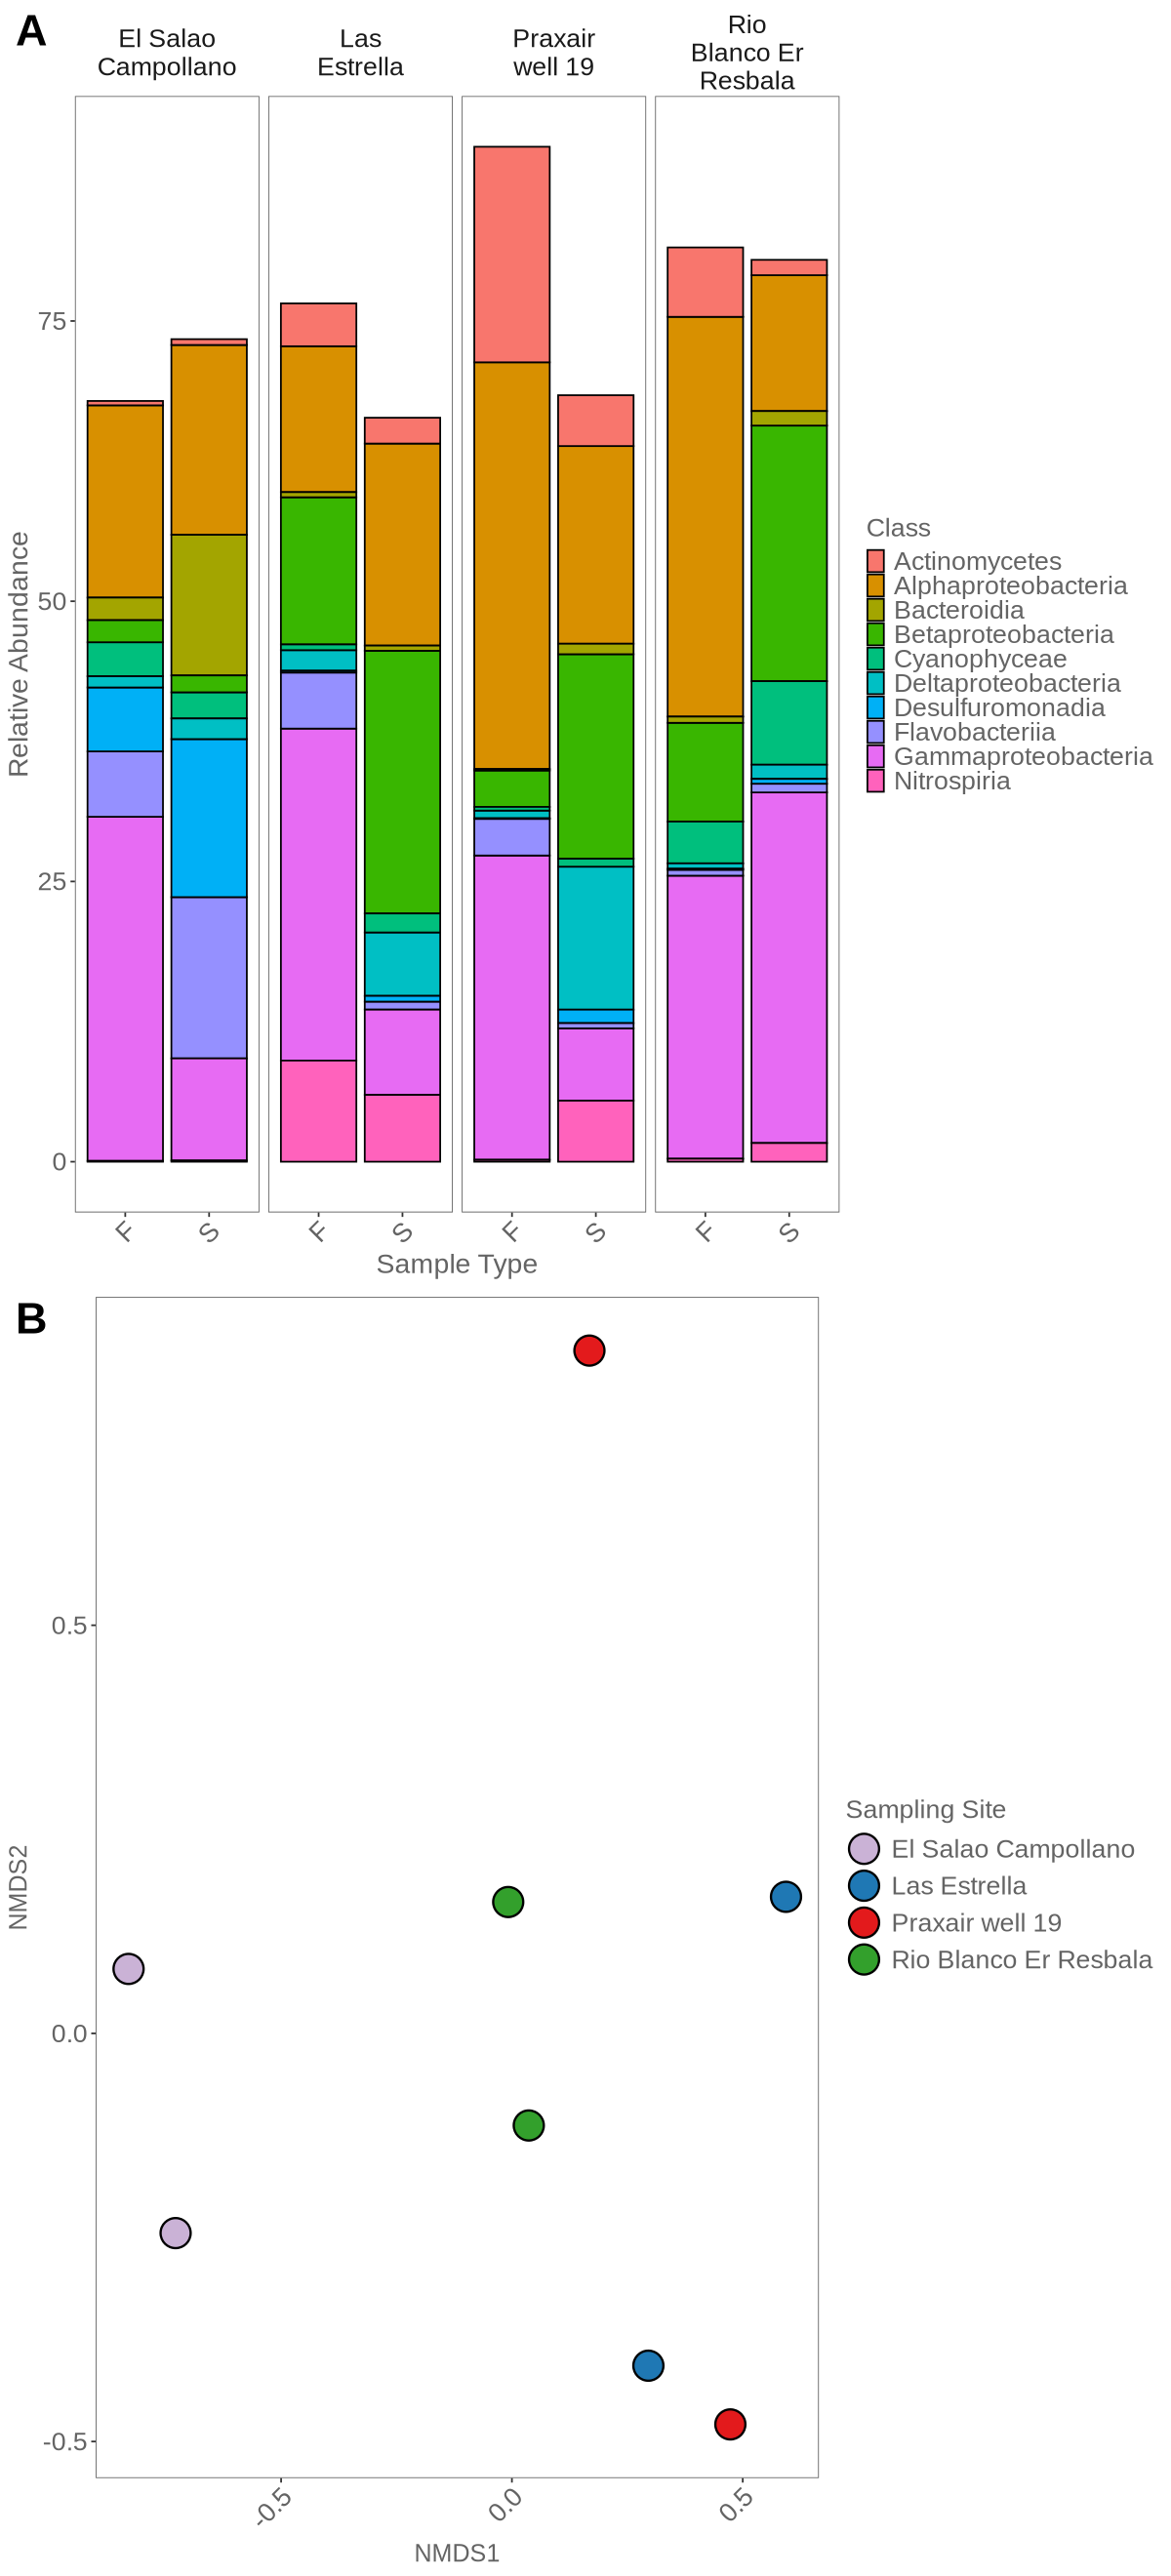

In [ ]:


left_col <- plot_grid(
  kaiju_class_2, nmds_weighted,
  labels      = c("A", "B"), 
  label_size = 27,
  ncol        = 1,             # side by side; use nrow = 2 to stack vertically
  align       = "v",           # align vertically (top/bottom edges)
  axis        = "tb",
  rel_widths  = c(1, 1)      # barplot is wider (facets) than NMDS, adjust to taste
)
left_col
ggsave(paste0(output_dir, "combined_plot_figure_3_vertical.png"), width = 10, height = 18, dpi = 300)
ggsave(paste0(output_dir, "combined_plot_figure_3_vertical.svg"), width = 10, height = 18, dpi = 300)

In [ ]:
library(png)
library(grid)
library(ggpubr)
img_kegg_decoder_v <- readPNG("/home/edo/working_dir/paper_images/kegg_decoder_vertical_1.png")
kegg_decoder_v1 <- as_ggplot(rasterGrob(img_kegg_decoder_v, interpolate = TRUE))

In [ ]:
options(repr.plot.width = 18, repr.plot.height = 26)

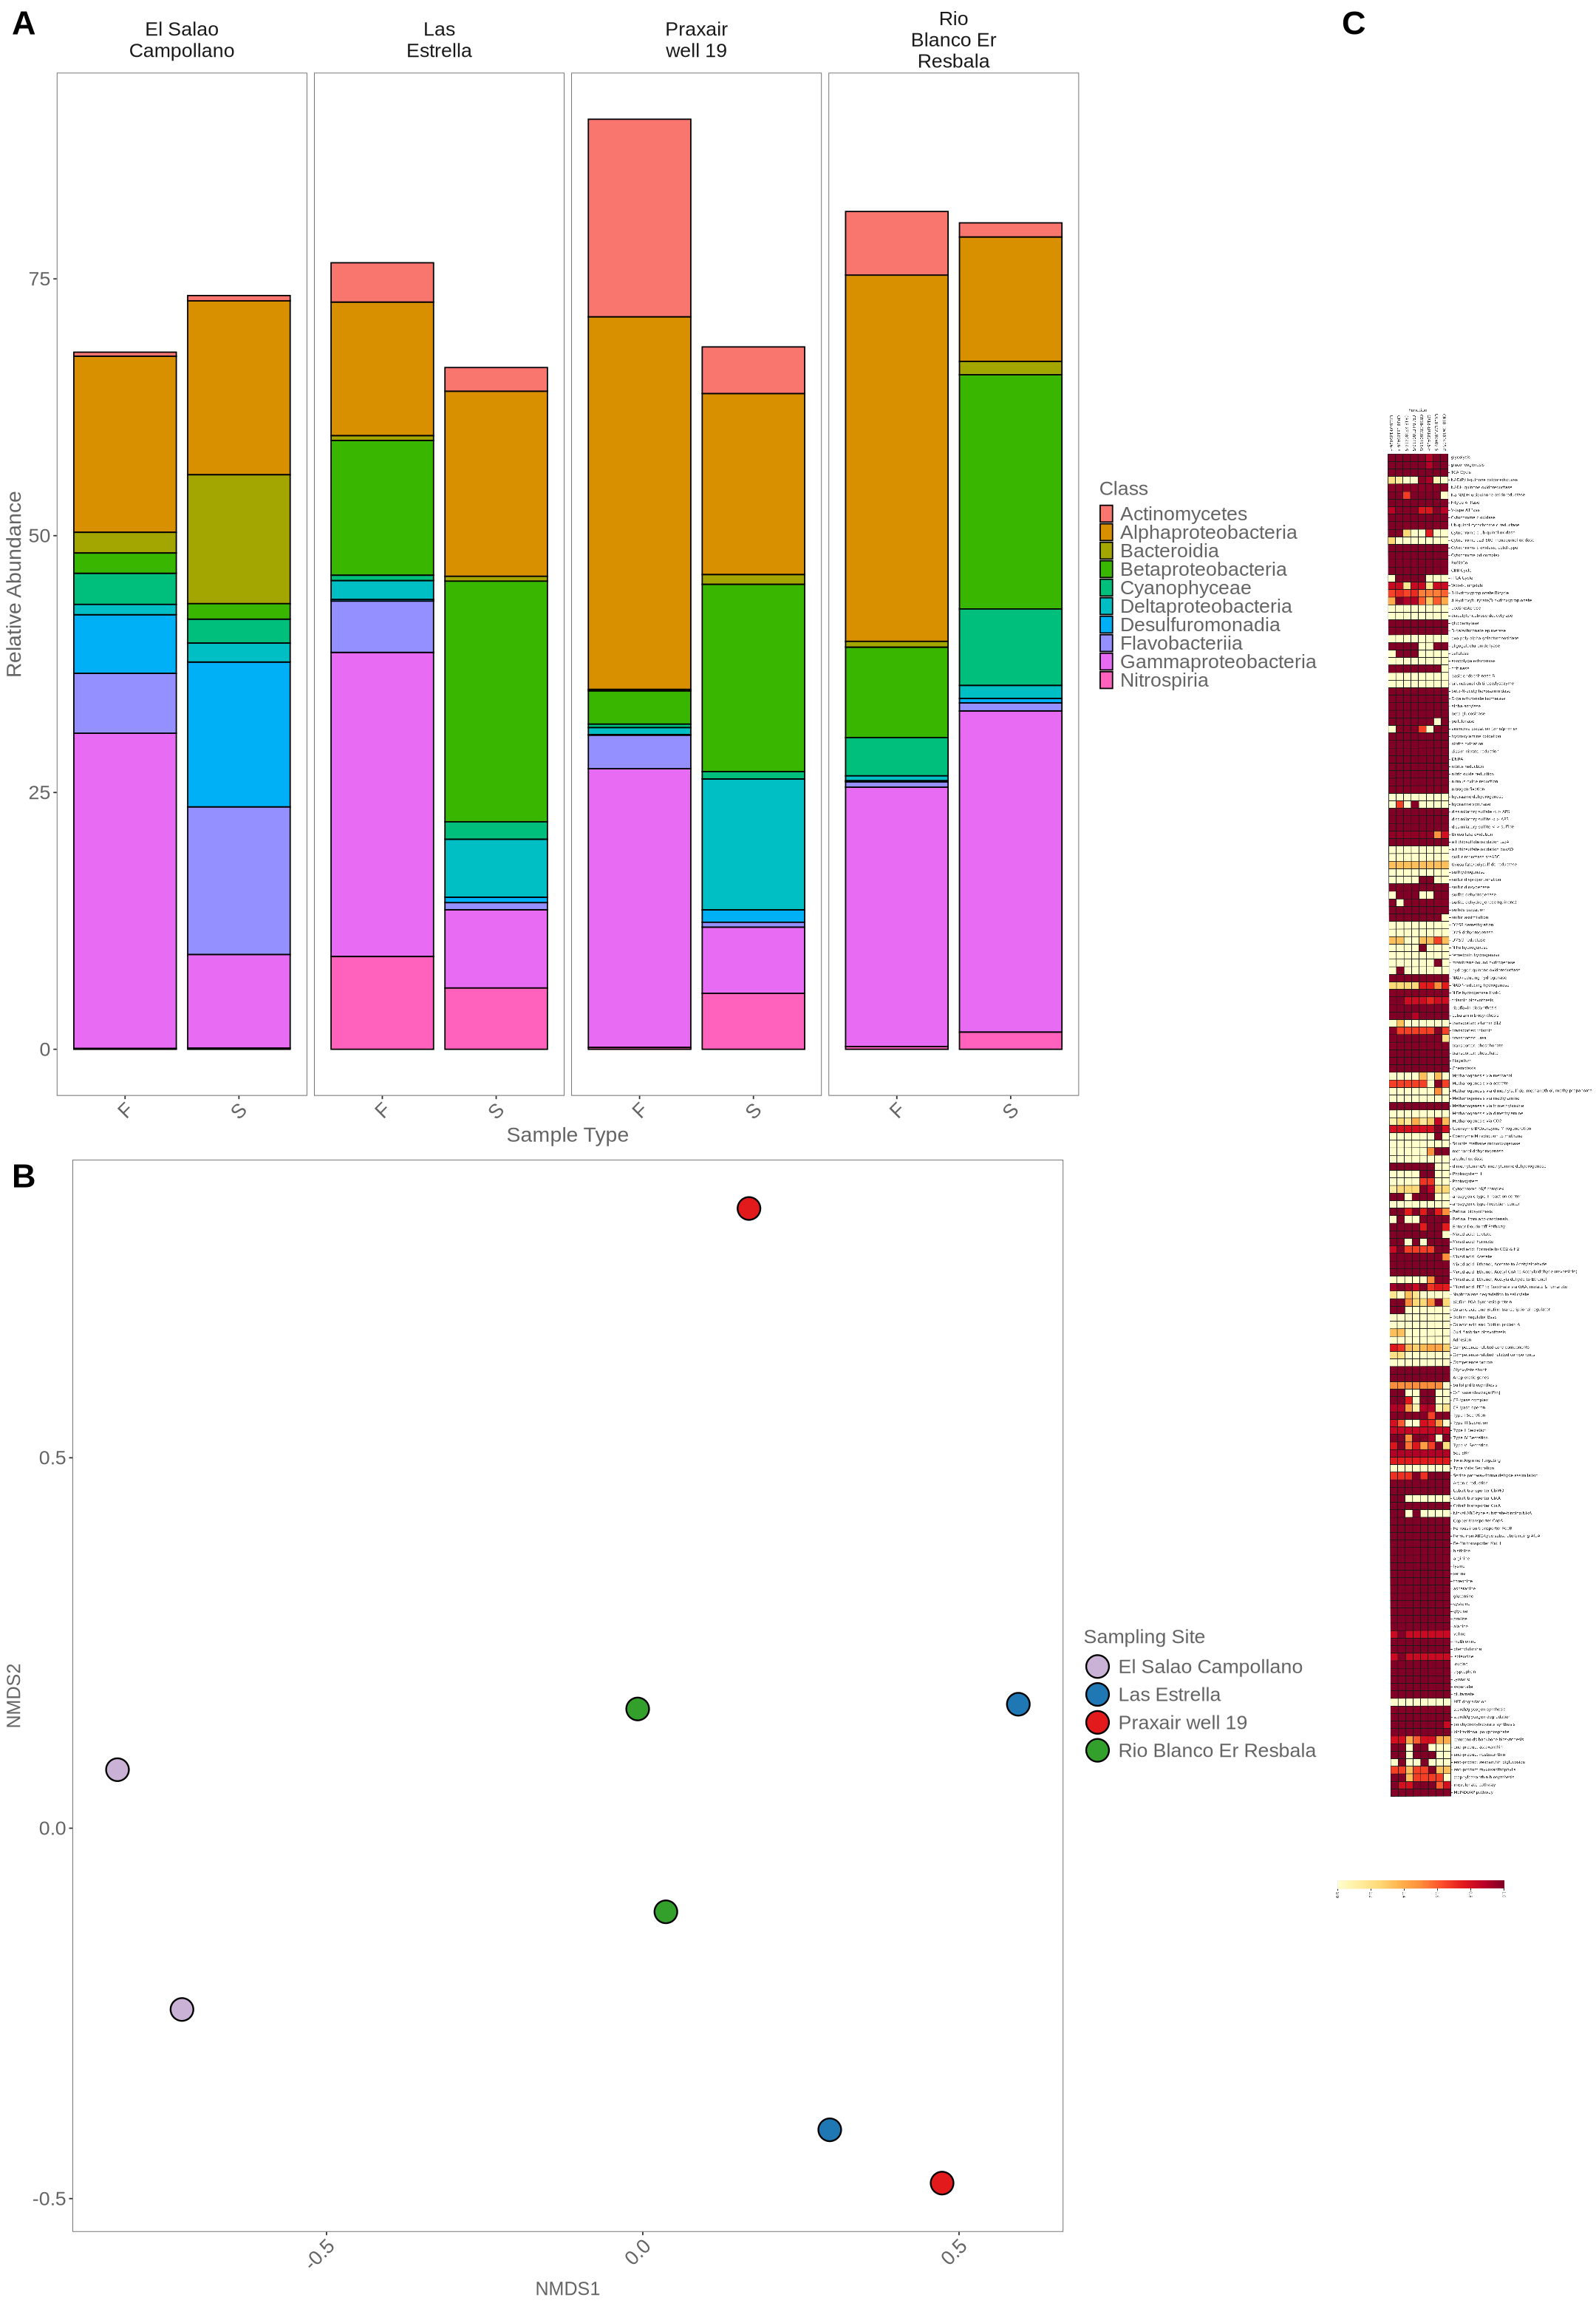

In [ ]:
# Step 2: stack the top row with panel C underneath
combined_plot_v <- plot_grid(
  left_col, kegg_decoder_v1,
  labels      = c("", "C"),   # A/B labels already applied in top_rowoptions(repr.plot.width = 10, repr.plot.height = 22)
  label_size  = 27,
  ncol        = 2,
  align       = "v",           # align vertically (top/bottom edges)
  rel_heights = c(1, 1),
  rel_widths = c(1, 0.2)      # adjust ratio: how wide the heatmap is vs A+B row
)

combined_plot_v
ggsave(paste0(output_dir, "combined_plot_figure_3_tris_v.png"), width = 14, height = 16, dpi = 300)
ggsave(paste0(output_dir, "combined_plot_figure_3_tris_v.svg"), width = 14, height = 16 , dpi = 300)

In [ ]:
img_kegg_decoder_v2 <- readPNG("/home/edo/working_dir/paper_images/kegg_decoder_vertical_2.png")
kegg_decoder_v2 <- as_ggplot(rasterGrob(img_kegg_decoder_v2, interpolate = TRUE))

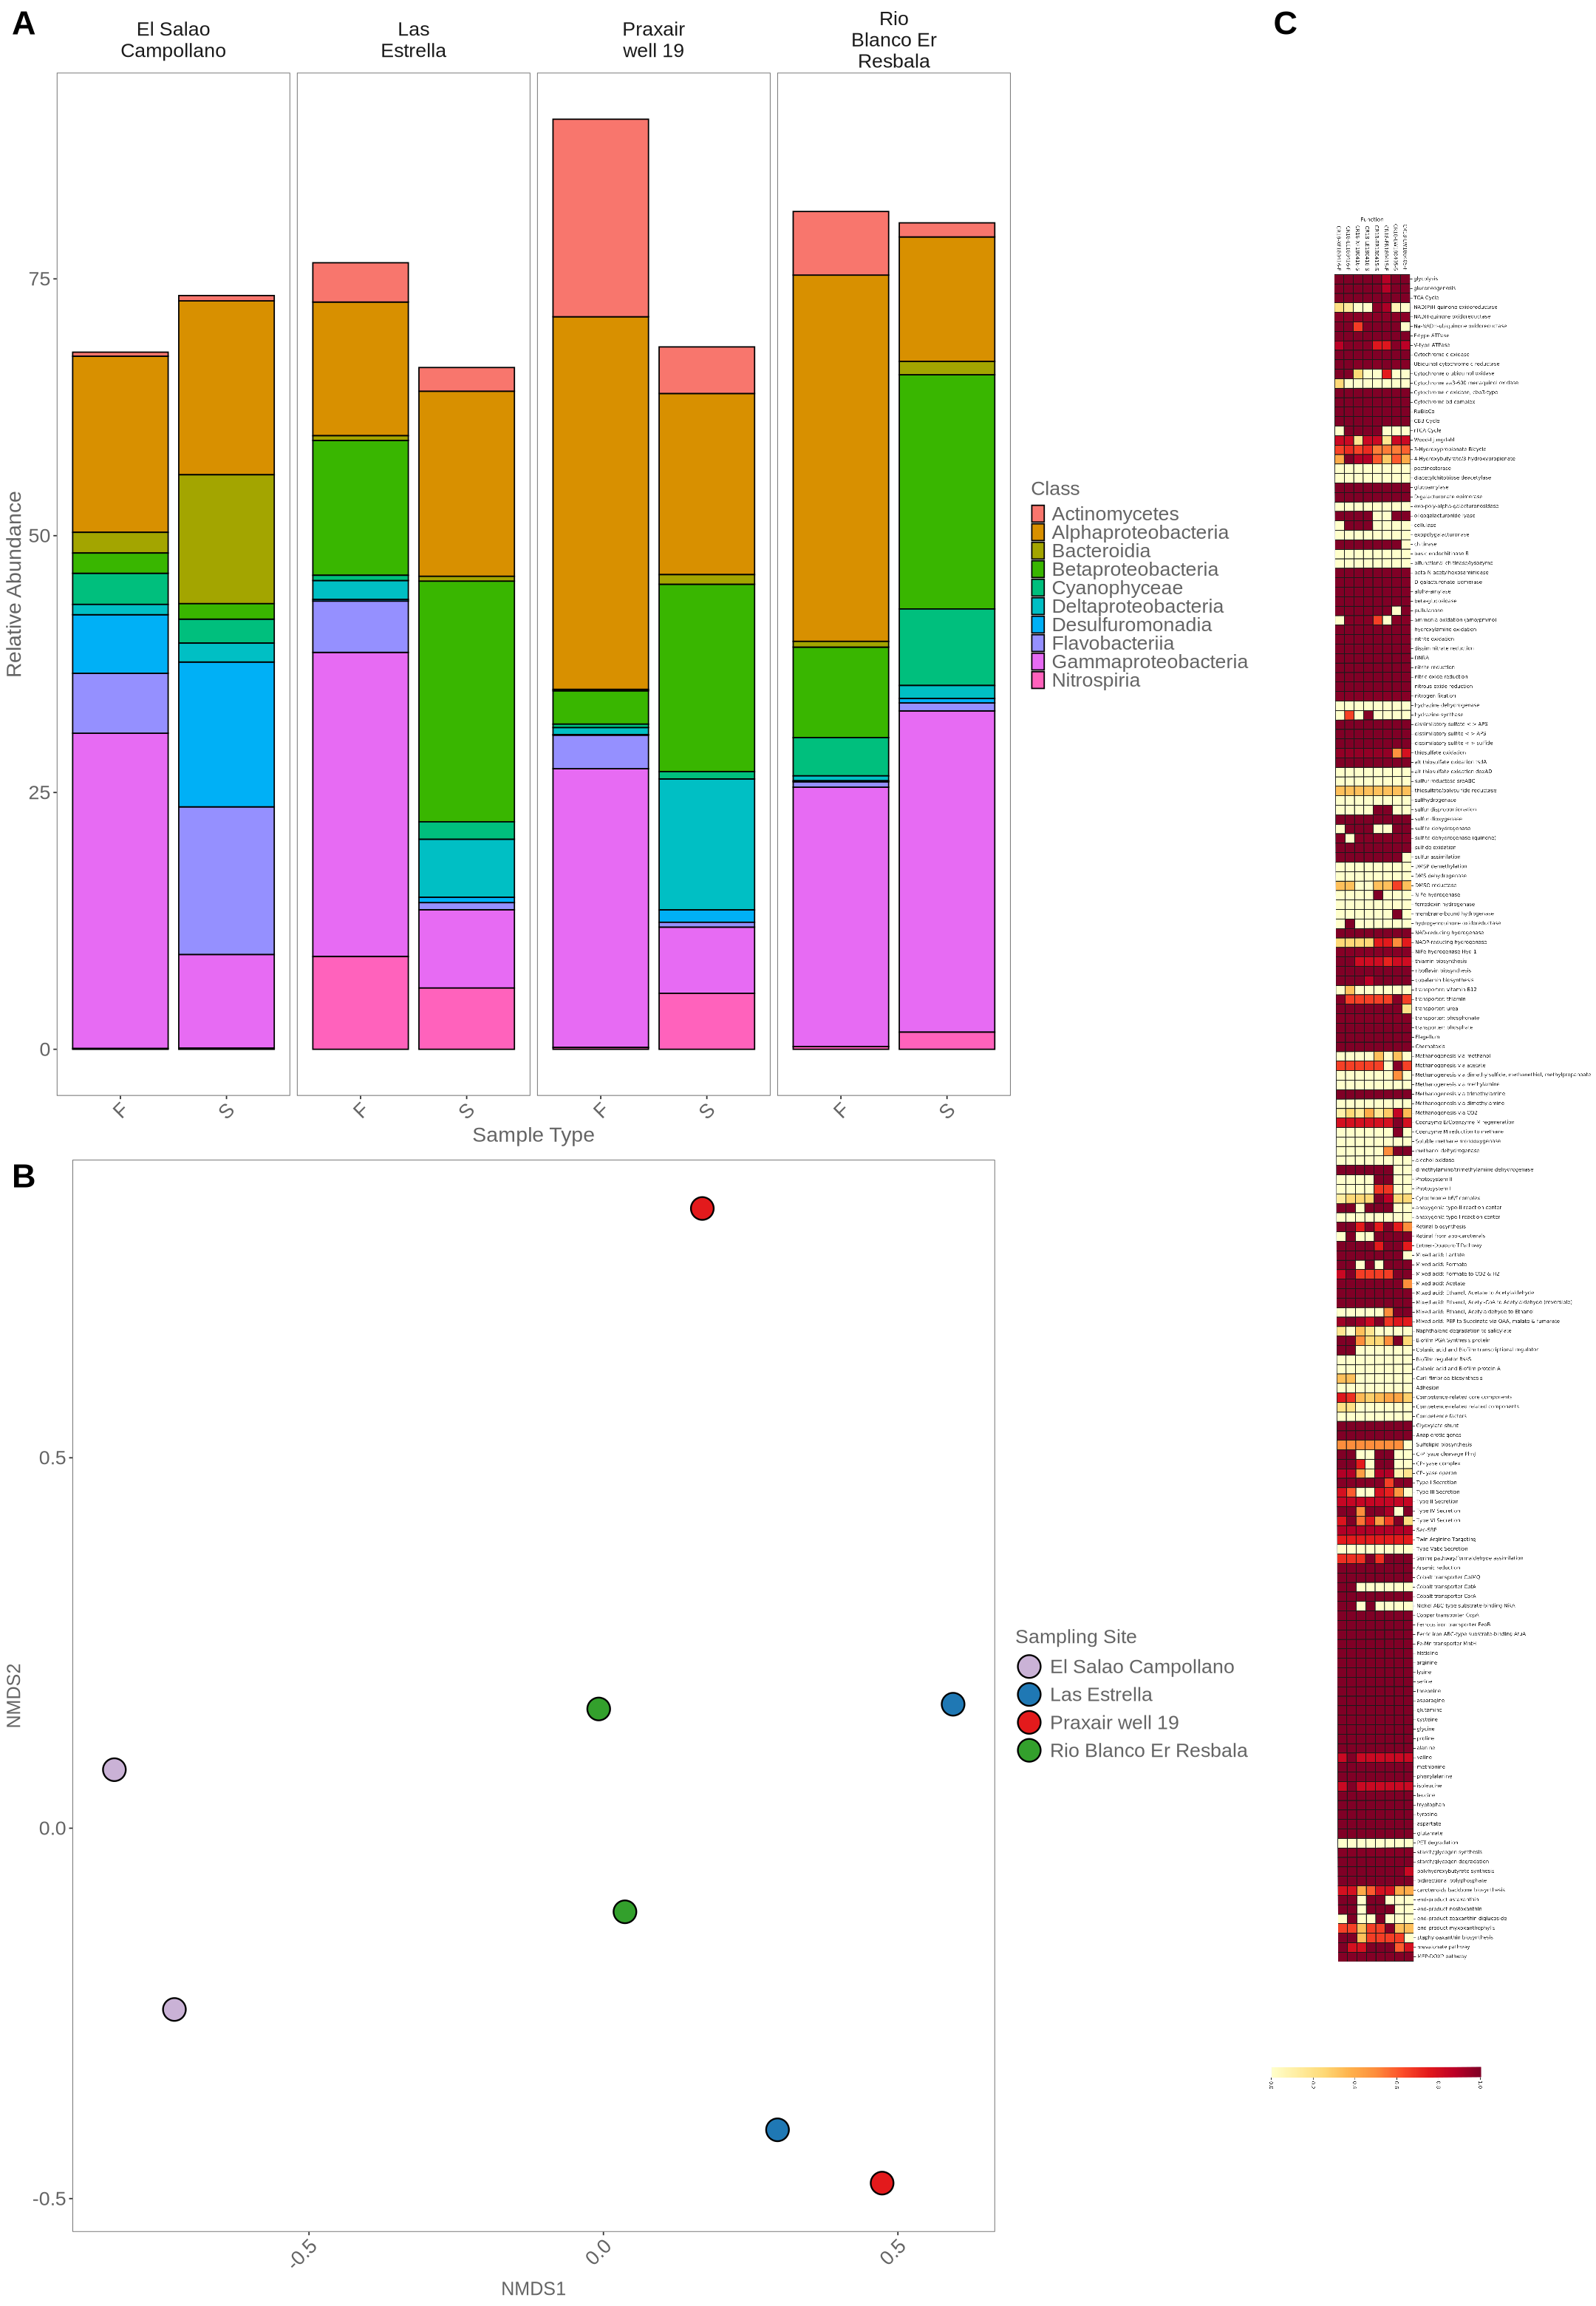

In [ ]:
# Step 2: stack the top row with panel C underneath
combined_plot_v2 <- plot_grid(
  left_col, kegg_decoder_v2,
  labels      = c("", "C"),   # A/B labels already applied in top_rowoptions(repr.plot.width = 10, repr.plot.height = 22)
  label_size  = 27,
  ncol        = 2,
  align       = "v",           # align vertically (top/bottom edges)
  rel_heights = c(1, 1),
  rel_widths = c(1, 0.265)      # adjust ratio: how wide the heatmap is vs A+B row
)

combined_plot_v2
ggsave(paste0(output_dir, "combined_plot_figure_3_tris_v2.png"), width = 12, height = 14, dpi = 300)
ggsave(paste0(output_dir, "combined_plot_figure_3_tris_v2.svg"), width = 12, height = 14 , dpi = 300)

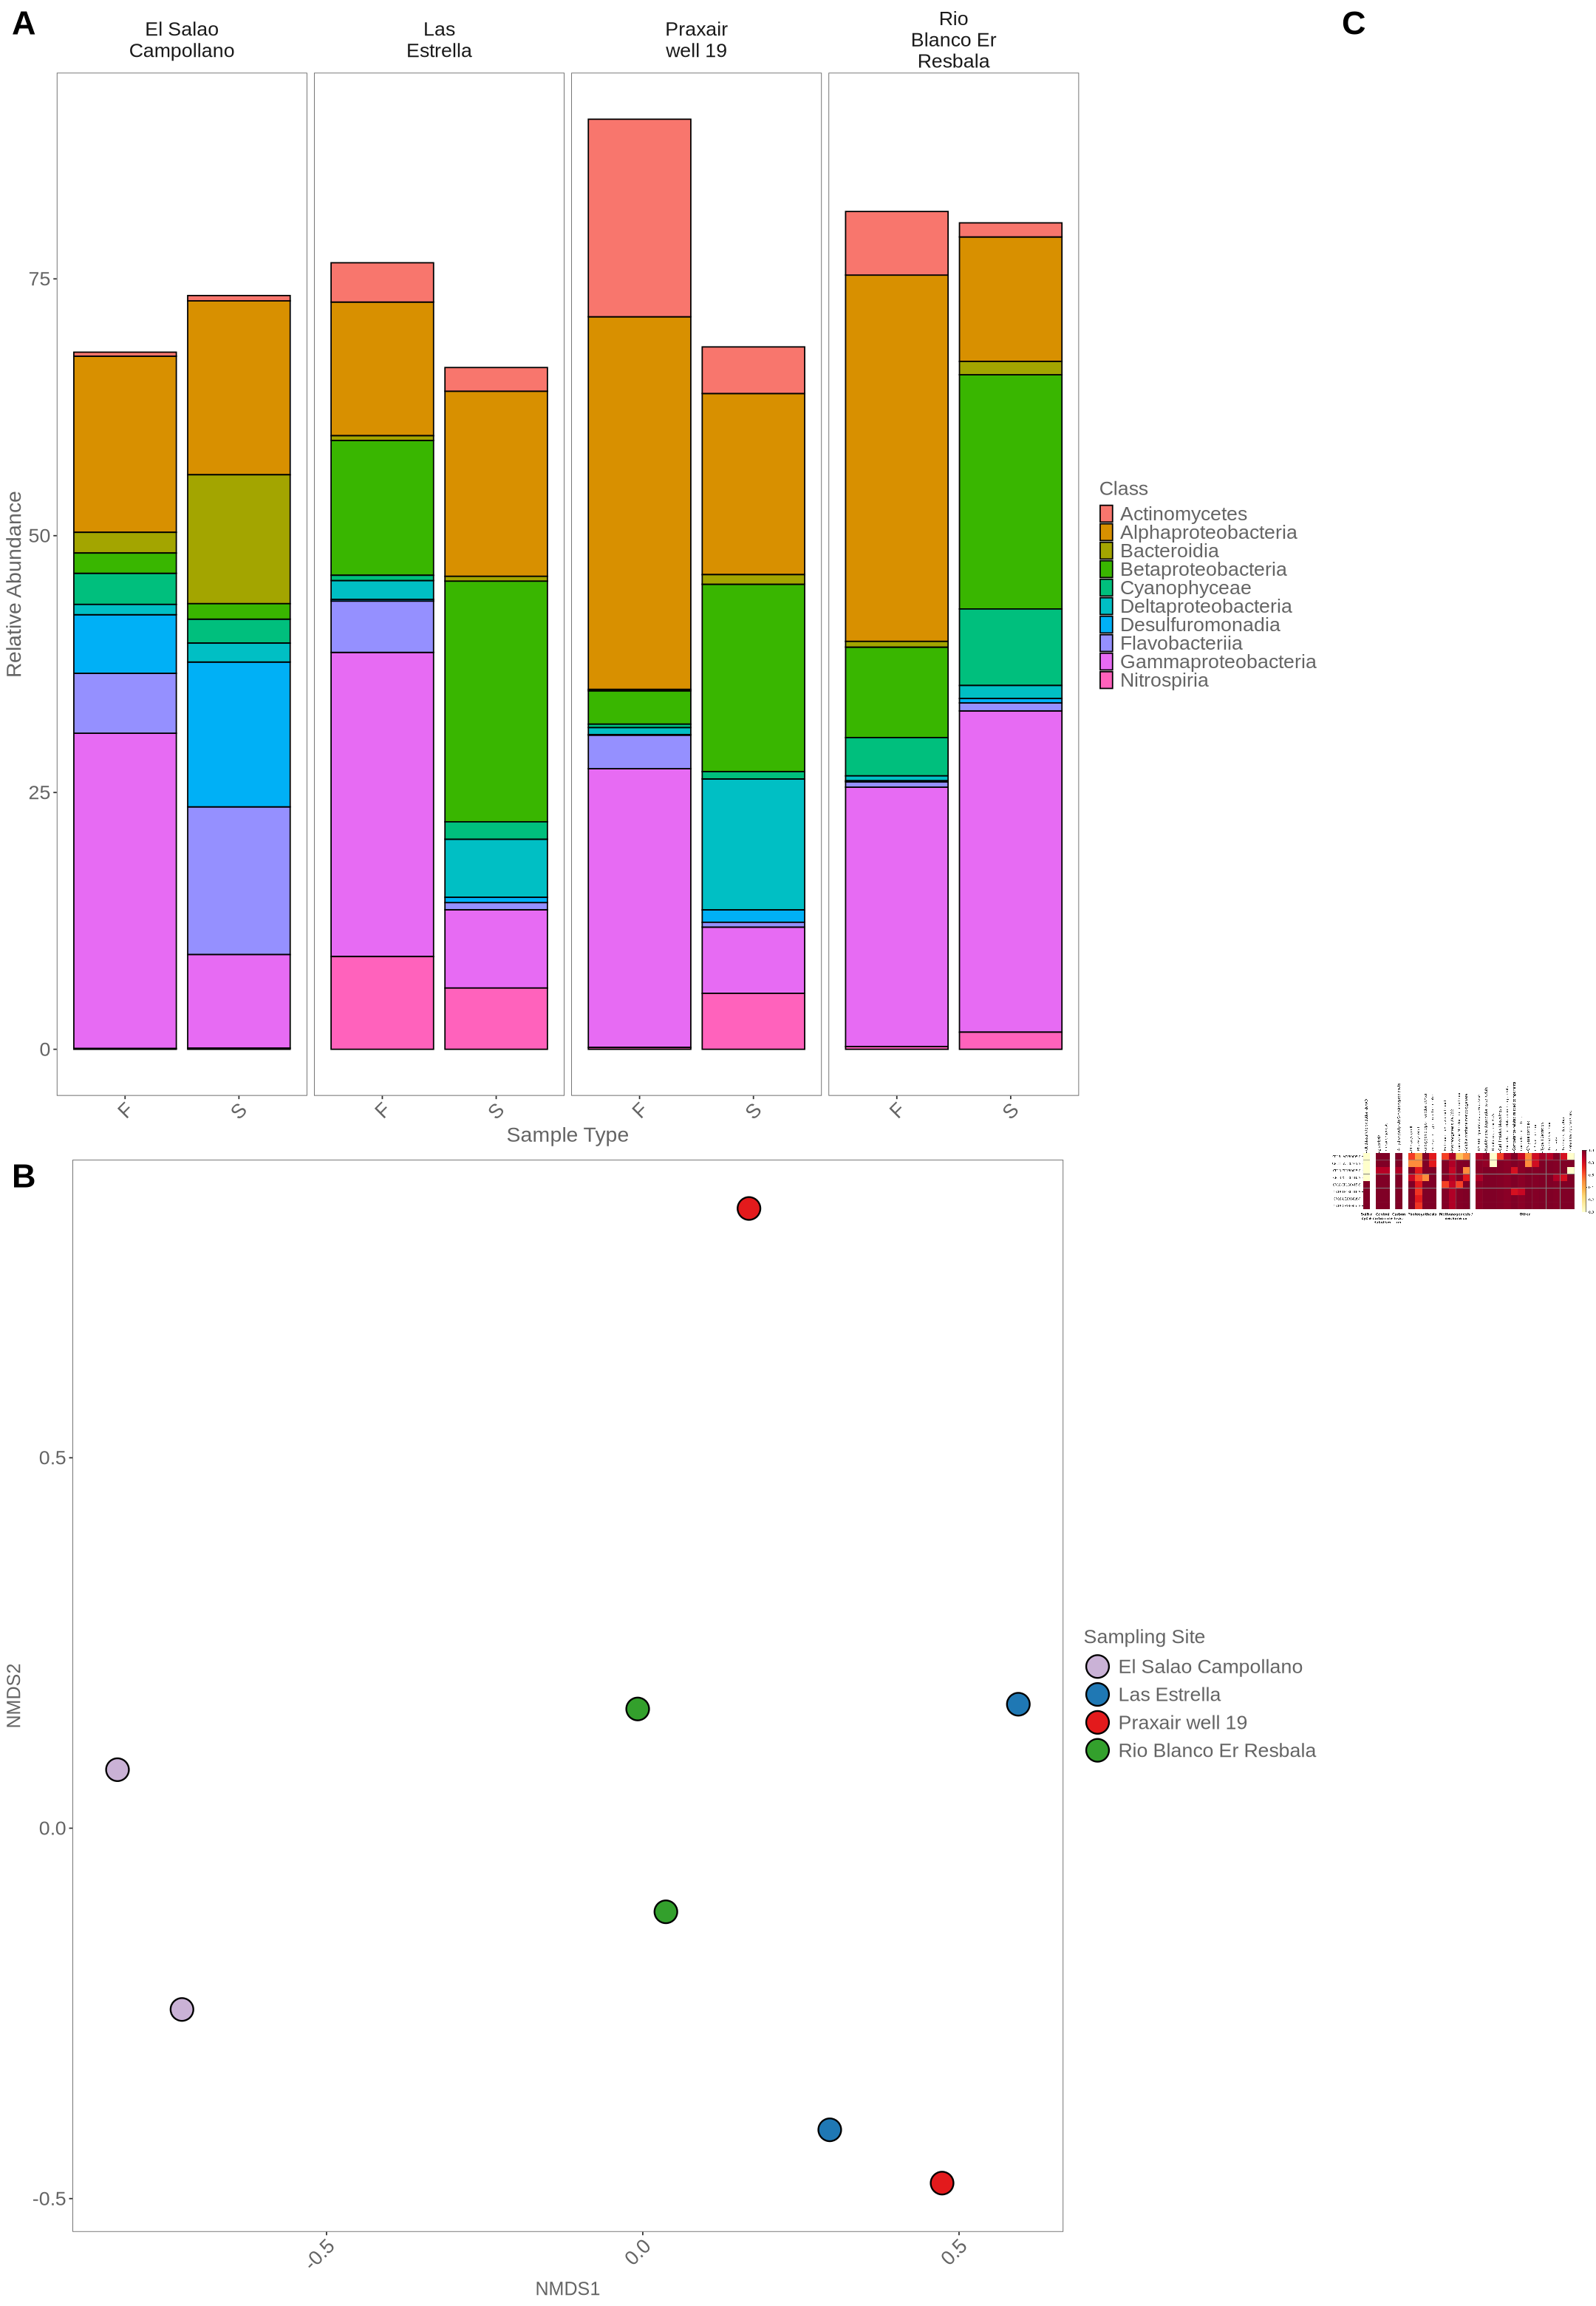

In [ ]:
# Step 2: stack the top row with panel C underneath
combined_plot_v <- plot_grid(
  left_col, kegg_decoder_v,
  labels      = c("", "C"),   # A/B labels already applied in top_rowoptions(repr.plot.width = 10, repr.plot.height = 22)
  label_size  = 27,
  ncol        = 2,
  align       = "v",           # align vertically (top/bottom edges)
  rel_heights = c(1, 1),
  rel_widths = c(1, 0.2)      # adjust ratio: how wide the heatmap is vs A+B row
)

combined_plot_v
ggsave(paste0(output_dir, "combined_plot_figure_3_tris_v1.png"), width = 12, height = 14, dpi = 300)
ggsave(paste0(output_dir, "combined_plot_figure_3_tris_v1.svg"), width = 12, height = 14 , dpi = 300)

In [ ]:
library(png)
library(grid)
library(ggpubr)
img_kegg_decoder <- readPNG("/home/edo/Downloads/kegg_decoder_output.png")
kegg_decoder <- as_ggplot(rasterGrob(img_kegg_decoder, interpolate = TRUE))

In [ ]:
options(repr.plot.width = 22, repr.plot.height = 12)

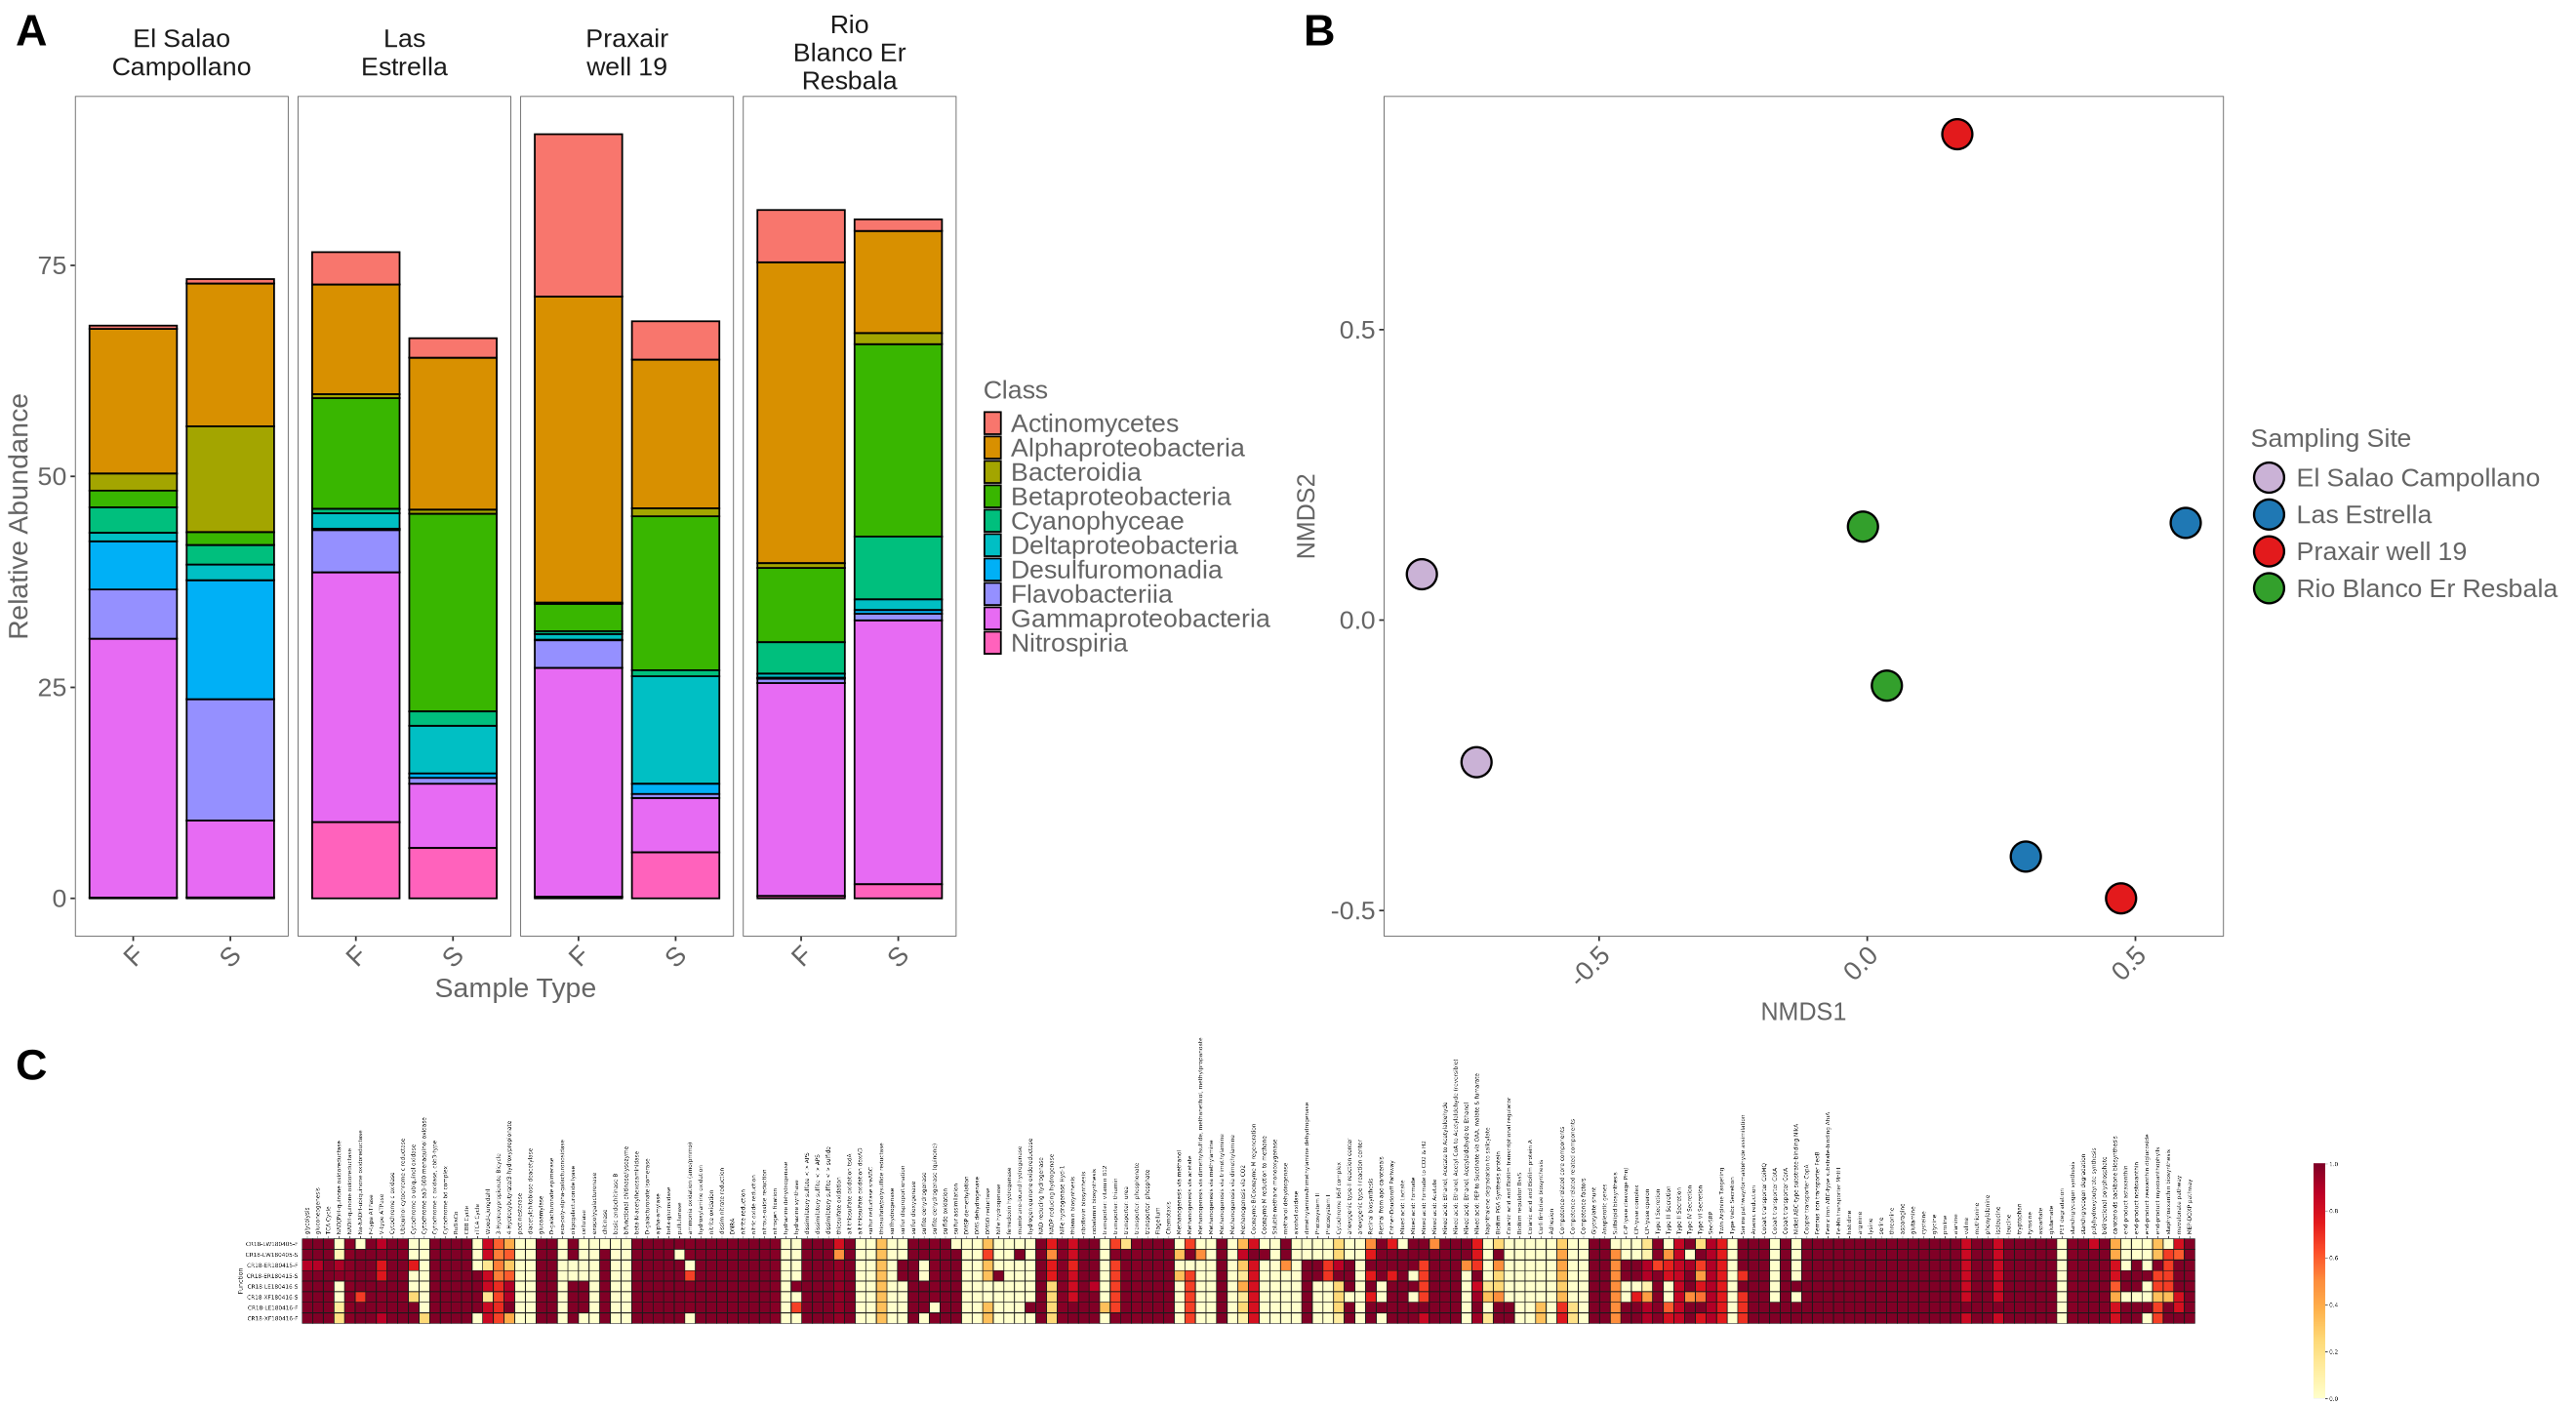

In [ ]:
# Step 2: stack the top row with panel C underneath
combined_plot <- plot_grid(
  top_row, kegg_decoder,
  labels      = c("", "C"),   # A/B labels already applied in top_row
  label_size  = 27,
  ncol        = 1,
  rel_heights = c(1, 0.3582)     # adjust ratio: how tall the heatmap is vs A+B row
)

combined_plot
ggsave(paste0(output_dir, "combined_plot_figure_3_tris.png"), width = 24, height = 16, dpi = 300)
ggsave(paste0(output_dir, "combined_plot_figure_3_tris.svg"), width = 24, height = 16 , dpi = 300)

img_plot_kaiju <- readPNG("~/Downloads/test_4_itol_tree.png")
itol_tree_4 <- as_ggplot(rasterGrob(img_plot_kaiju, interpolate = TRUE))

#img_kegg_decoder <- readPNG("/home/edo/working_dir/paper_images/kegg_decoder_output.png")
kegg_decoder <- as_ggplot(rasterGrob(img_kegg_decoder, interpolate = TRUE))

combined_plot <- plot_grid(
  img_plot_kaiju, kegg_decoder,
  labels      = c("A", "B"), 
  label_size = 27,
  ncol        = 2,             # side by side; use nrow = 2 to stack vertically
  align       = "h",           # align horizontally (top/bottom edges)
  axis        = "tb",
  rel_widths  = c(1, 1)      # barplot is wider (facets) than NMDS, adjust to taste
)
combined_plot
